MT Data-conditioned VAE

CVAE/VAE code trained on Line 1 Central Region, with Line 3 as validation and Line 2 as test 1 (eventually - next step is to get test set(s) finalized and included in code)

In [76]:
# pip install tensorflow[and-cuda]

In [77]:
%load_ext autoreload
%autoreload 2

import os
import time
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import csv
import scipy as sp
from scipy import interpolate
# import scipy.interpolate

from cgnn import cvae_mt64_updated as vae

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
# import tensorflow as tf

# print(tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: []


In [79]:
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy("mixed_float16")
tf.keras.mixed_precision.set_global_policy("float32")


tf.keras.mixed_precision.set_global_policy("float32")

In [80]:
run = 's4'
if not os.path.exists(run):
    os.makedirs(run)

# Set up survey

In [81]:
def import_file(file):
    with open(file, 'r') as f:
        reader = csv.reader(f)
        data = list(reader)
    line = np.array(data, dtype=float)
    cond = line[:,25:55]
    # obs_xs = line[:,270:285]
    # print(obs_xs.shape)
    obs_zs = -line[:,286:301]
    print(obs_zs.shape)
    print(cond.shape)
    # obs_total = np.concatenate((obs_xs, obs_zs), axis=1)
    # print(obs_total.shape)
    pred_zs = line[:,348:363]
    return line,cond, obs_zs, pred_zs

In [82]:
# line1,cond1, obs1, pred1 = import_file('Line1_Central-Copy1.csv')
# line2,cond2, obs2, pred2 = import_file('Line2_Central-Copy1.csv')
# line3,cond3, obs3, pred3 = import_file('Line3_Central-Copy1.csv')



# print(obs1)

In [83]:
# line94, cond94, obs94, pred94 = import_file('Central_Line94.csv')

# line15, cond15, obs15, pred15 = import_file('Central_Line15.csv')
# line30, cond30, obs30, pred30 = import_file('Central_Line30.csv')
# line45, cond45, obs45, pred45 = import_file('Central_Line45.csv')
# line60, cond60, obs60, pred60 = import_file('Central_Line60.csv')
# line75, cond75, obs75, pred75 = import_file('Central_Line75.csv')
# print(cond15)

In [84]:
# np.save('Line94_Central.npy', line94)
# np.save('Line94_Central_Conductivity.npy',cond94)
# np.save('Line94_Central_Observations.npy',obs94)

In [85]:
# remote reference frequencies
#   7.680002e+02   5.120000e+02   3.840000e+02   2.560000e+02   1.920000e+02   1.280000e+02
#   9.599997e+01   6.400000e+01   4.800001e+01   3.200000e+01   2.400000e+01   1.600000e+01
#   1.200000e+01   8.000000e+00   5.999999e+00   4.000000e+00   3.000000e+00   2.000000e+00
#   1.500000e+00   1.000000e+00   7.500002e-01   5.000000e-01   3.750000e-01   2.500000e-01
#   1.875000e-01


# mesh
# 64 ft
cell_size = 32*0.3048
depth_to_top = 32*0.3048
n_cells = 32
# one fewer depth; last cell extends to inf
#depths = depth_to_top + np.arange(1,n_cells)*cell_size
#depths to bottom
depths0 = np.array([4,8.4,13.24,18.56,24.42,30.86,37.95,45.74,54.31,63.74,74.11,85.52,98.07,111.88,127.07,143.78,162.16,182.38,204.62,229.08,255.99,285.59,318.15,353.97,393.37,436.71,484.38,536.82,594.5])
n_depths = len(depths0)
print(n_depths)
# data frequencies
# conservative, lines up with remote referenced stations, minus one frequency to avoid extrapolation
f_a = np.logspace(-2, 9, num=12, base=2)
f_b = np.logspace(-4, 7, num=12, base=2)*3
time0 = np.array([0.013,0.039,0.065,0.104,0.169,0.273,0.443,0.703,1.094,1.693,2.63,4.102,6.406,9.961,16.055])*1e-3
# frequencies = np.logspace(-4, 10, 15, base=2)
nt = len(time0)
print(nt)
# data are only real
ndata = nt

29
15


In [86]:
# depth = np.append(0,depths0)

# def format_models(file, depths):
#     cond_new = np.zeros((len(file[:,0]),32))
#     for i in range(len(file[:,0])):
#         x = file[i]
#         y = depths
#         f = sp.interpolate.interp1d(y,x)
#         y_new = [554,573]
#         x_new = f(y_new)
#         cond_new[i] = np.append(x,x_new)
#     return cond_new

# cond94_new = format_models(cond94,depth)

# print(cond94_new.shape)
# print(len(depth))  
# # print(len(cond1_new[0]))
# # print(cond1_new[1])


In [87]:
# def format_raw(file,times):
#     obs_new = np.zeros((len(file[:,0]),16))
#     for i in range(len(file[:,0])):
#         x = file[i]
#         y = times
#         f = sp.interpolate.interp1d(y,x)
#         y_new = [16.054*1e-3]
#         x_new = f(y_new)
#         obs_new[i] = np.append(x,x_new)
#     return obs_new
    
# obs94_new = format_raw(obs94,time0)

# print(obs94_new.shape)
# print(len(time0))

In [88]:
# from scipy.spatial.distance import cosine

# # for i in range(0,1000,10):
# #     print(np.mean(cond1[i]-cond1[0]))
# #     # plt.plot(cond1[0],depth)
# #     # plt.plot(cond1[i],depth)
# #     # plt.gca().invert_yaxis()
# def compute_moving_average(models, window_size=5):
#     """
#     Apply moving average to each model (row) in the dataset.
#     """
#     return np.array([
#         np.convolve(model, np.ones(window_size)/window_size, mode='same')
#         for model in models
#     ])

# def select_diverse_models(models, threshold=0.01, metric='mse', window_size=5):
#     """
#     Select a diverse subset of models based on moving average smoothed values.

#     Parameters:
#     - models: np.ndarray of shape (N, 30)
#     - threshold: float, minimum difference to count as diverse
#     - metric: str, 'mse' or 'cosine'
#     - window_size: int, size of the moving average window

#     Returns:
#     - indices: np.ndarray of selected row indices
#     """
#     smoothed = compute_moving_average(models, window_size)
#     selected = [0]  # Always include the first model

#     for i in range(1, len(smoothed)):
#         prev_model = smoothed[selected[-1]]
#         curr_model = smoothed[i]

#         if metric == 'mse':
#             diff = np.mean((curr_model - prev_model)**2)
#         elif metric == 'cosine':
#             diff = cosine(curr_model, prev_model)
#         else:
#             raise ValueError("Unsupported metric. Use 'mse' or 'cosine'.")

#         if diff > threshold:
#             selected.append(i)

#     return np.array(selected)

In [89]:
# print(cond1.shape)

In [90]:
# # Select diverse subset
# diverse_indices1 = select_diverse_models(cond1, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models1 = cond1[diverse_indices1]
# diverse_data1 = obs1[diverse_indices1]
# print(len(diverse_models1), len(diverse_data1))

# print(f"Selected {len(diverse_indices1)} diverse models from {len(cond1)} total")
# print(diverse_models1.shape)

# # Select diverse subset
# diverse_indices15 = select_diverse_models(cond15, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models15 = cond15[diverse_indices15]
# diverse_data15 = obs15[diverse_indices15]
# print(len(diverse_models15), len(diverse_data15))

# print(f"Selected {len(diverse_indices15)} diverse models from {len(cond15)} total")
# print(diverse_models15.shape)

# # Select diverse subset
# diverse_indices30 = select_diverse_models(cond30, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models30 = cond30[diverse_indices30]
# diverse_data30 = obs30[diverse_indices30]
# print(len(diverse_models30), len(diverse_data30))

# print(f"Selected {len(diverse_indices30)} diverse models from {len(cond30)} total")

# # Select diverse subset
# diverse_indices45 = select_diverse_models(cond45, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models45 = cond45[diverse_indices45]
# diverse_data45 = obs45[diverse_indices45]
# print(len(diverse_models45), len(diverse_data45))

# print(f"Selected {len(diverse_indices45)} diverse models from {len(cond45)} total")

# # Select diverse subset
# diverse_indices60 = select_diverse_models(cond60, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models60 = cond60[diverse_indices60]
# diverse_data60 = obs60[diverse_indices60]
# print(len(diverse_models60), len(diverse_data60))

# print(f"Selected {len(diverse_indices60)} diverse models from {len(cond60)} total")

# # Select diverse subset
# diverse_indices75 = select_diverse_models(cond75, threshold=0.01, metric='mse', window_size=3)

# # Extract selected models
# diverse_models75 = cond75[diverse_indices75]
# diverse_data75 = obs75[diverse_indices75]
# print(len(diverse_models75), len(diverse_data75))

# print(f"Selected {len(diverse_indices75)} diverse models from {len(cond75)} total")

In [91]:
# cond1_sampled = format_models(diverse_models1,depth)
# obs1_sampled = format_raw(diverse_data1, time0)

# cond15_new = format_models(diverse_models15,depth)
# cond30_new = format_models(diverse_models30,depth)
# cond45_new = format_models(diverse_models45,depth)
# cond60_new = format_models(diverse_models60,depth)
# cond75_new = format_models(diverse_models75,depth)

# obs15_new = format_raw(diverse_data15,time0)
# obs30_new = format_raw(diverse_data30,time0)
# obs45_new = format_raw(diverse_data45,time0)
# obs60_new = format_raw(diverse_data60,time0)
# obs75_new = format_raw(diverse_data75,time0)

# print(cond1_sampled.shape)
# print(obs1_sampled.shape)
# print(cond75_new.shape)
# print(obs75_new.shape)

In [92]:
# cond_sampled = np.append(cond1_sampled,cond15_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond30_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond45_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond60_new,axis=0)
# cond_sampled = np.append(cond_sampled,cond75_new,axis=0)

# obs_sampled = np.append(obs1_sampled, obs15_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs30_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs45_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs60_new, axis=0)
# obs_sampled = np.append(obs_sampled, obs75_new, axis=0)

# print(cond_sampled.shape)
# print(obs_sampled.shape)

In [93]:
# --- Step 1: Load sampling pattern ---
# # If your Excel file is actually saved as CSV, use this:
# pattern = np.loadtxt('1D_ergodic_100_50.csv', delimiter=',', dtype=int)

# # Flatten in case it’s multi-dimensional (e.g., 100×1 or 1×100)
# pattern = pattern.flatten()
# pattern_length = len(pattern)
# print(f"Pattern length: {pattern_length}")

# # --- Step 2: Load the large dataset (.npy file) ---
# # data = np.load('large_dataset.npy')
# model_length = len(cond_sampled)
# data_length = len(obs_sampled)

# print(f"Model length: {model_length}, Data length: {data_length}")

# # --- Step 3: Repeat pattern to cover the full dataset ---
# repeats = int(np.ceil(data_length / pattern_length))
# repeated_pattern = np.tile(pattern, repeats)[:data_length]

# # --- Step 4: Apply ergodic sampling mask ---
# sampled_models = cond_sampled[repeated_pattern == 1]
# sampled_data = obs_sampled[repeated_pattern == 1]

# # --- Step 5: Save or return sampled data ---
# # np.save('ergodic_sampled_output.npy', sampled_data)

# print(f"Sampled {len(sampled_models)} and {len(sampled_data)} of {model_length} and {data_length} total points "
#       f"({len(sampled_models) / model_length:.1%})."
#       f"({len(sampled_data) / data_length:.1%})")

# print(sampled_models.shape)

In [94]:
# np.save('Sampled_Conductivity.npy',sampled_models)
# np.save('Sampled_Observations.npy',sampled_data)

In [95]:
depths=np.append(depths0,[554,573])
print(depths.shape)

# np.save('Line94_Central_Conductivity.npy',cond94_new)

(31,)


In [96]:
times = np.append(time0,16.054*1e-3)
times.sort()
print(len(times))

# np.save('Line94_Central_Observations.npy',obs94_new)

16


In [97]:
# x = np.arange(depths.size)
# new_length = 63
# new_x = np.linspace(x.min(), x.max(), new_length)
# new_depths = sp.interpolate.interp1d(x, depths)(new_x)
# print(new_depths)
# print(len(new_depths))
# depths = new_depths

# Load training models and Create neural network

In [98]:
# normalize model parameters between -1 and 1
# remember, min resistivity is 0.01, max is 1e5
# Gaussian infill potentially allows for values outside this range, but not likely
min_model = np.log(1e-5)
max_model = np.log(1e5)
# pad by norm_pad, so that a bunch of values don't end up at -1
norm_pad = 0.1

# create network
network = vae.CVAE(depths,
                   min_model=min_model,
                   max_model=max_model,
                   times = times,
                   norm_pad=norm_pad,
                   data_std=0.1,
                   model_std=.01,
                   beta_vae=0.1,
                   model_loss_type='mae',
                   data_loss_type='mae'
                  )

# model = CVAE(latent_dim, channels, initializer)
print(hasattr(network, "z_mean"), hasattr(network, "z_logvar"))

True True


In [99]:
# Due to ranging orders of magnitude - recommended to keep
def preprocess(filename):
    '''
    Read RILD values from npy file
    Convert to log conductivity
    Reshape to include channel dimension
    '''
    x = np.log(np.load(filename))
    x = x.reshape(-1, n_cells, 1)
    return x

x_train_log = preprocess('Sampled_Conductivity.npy')
print(x_train_log.shape)
x_validate_log = preprocess('Line3_Central_Conductivity.npy')
x_test_log = preprocess('Line2_Central_Conductivity.npy')
x_test_log94 = preprocess('Line94_Central_Conductivity.npy')
# x_test2_log = preprocess('KGS_RILD_64ft_test2.npy')
# print(x_train_log)

x_train_raw = np.load('Sampled_Observations.npy')
x_validate_raw = np.load('Line3_Central_Observations.npy')
x_test_raw = np.load('Line2_Central_Observations.npy')
print(x_test_raw.shape)
x_test_raw94 = np.load('Line94_Central_Observations.npy')
print(x_test_raw94.shape)
#print(x_train_raw_log)

# x_train_raw = network.model_to_tanhs(x_train_raw_log)
# x_validate_raw = network.model_to_tanhs(x_validate_raw_log)
# x_test1_raw = network.model_to_tanhs(x_test1_raw_log)

x_train = network.model_to_tanhs(x_train_log)
x_validate = network.model_to_tanhs(x_validate_log)
x_test = network.model_to_tanhs(x_test_log)
x_test94 = network.model_to_tanhs(x_test_log94)
# x_test2 = network.model_to_tanhs(x_test2_log)
# print(x_train)
# print(np.max(x_train))

AuEM_models1 = np.load('Sampled_Conductivity.npy')
AuEM_models2 = np.load('Line2_Central_Conductivity.npy')
AuEM_models3 = np.load('Line3_Central_Conductivity.npy')

(2701, 32, 1)
(3355, 16)
(5748, 16)


In [100]:
print(x_train.shape)
print(x_validate.shape)
print(x_train_raw.shape)
print(x_validate_raw.shape)

x_train1 = x_train
# print(x_train1)
x_validate1 = x_validate[0:3000,]
x_train_raw1 = x_train_raw
x_validate_raw1 = x_validate_raw[0:3000,]
# x_test_raw1 = x_test_raw[0:1000,]
# print(x_train_raw1)
# plt.plot(x_train_raw1[0],np.append(0,depths))

(2701, 32, 1)
(17419, 32, 1)
(2701, 16)
(17419, 16)


In [101]:
# compute stds
model_std = np.std(x_train.flatten())
#mt_data_file = 'KGS_MT.npy'
#os.remove(mt_data_file)
#try:
#    all_data = tf.convert_to_tensor(np.load(mt_data_file))
#except FileNotFoundError:
#    all_data = network.predict_tanh(x_train)
#    np.save(mt_data_file, all_data.numpy())
train_data = x_train1[:,:,0]
# print(train_data)
# print("train data", train_data.shape)
# print('.........')


raw_train = np.asarray(x_train_raw1.T)
print(np.shape(raw_train[:,0]))
print(times)
raw_train_T = raw_train*1e-15
raw_train_data = np.gradient(raw_train_T,times, axis=0)
raw_train_data = -np.abs(raw_train_data).T
# log_train_data = tf.math.log(-train_data)
#print('log_train_data'log_train_data.shape)
print("raw_train_data", raw_train_data.shape)
print(raw_train_data[0])
raw_validate = np.asarray(x_validate_raw1.T)
raw_validate_T = raw_validate*1e-15
raw_validate_data = np.gradient(raw_validate_T,times, axis=0)
raw_validate_data = -np.abs(raw_validate_data).T
validate_data = x_validate1[:,:,0]
# raw_validate_data = -x_validate_raw1

raw_test = np.asarray(x_test_raw.T)
raw_test_T = raw_test*1e-15
print(raw_test_T.shape)
raw_test_data = np.gradient(raw_test_T,times, axis=0)
raw_test_data = -np.abs(raw_test_data).T

raw_test94 = np.asarray(x_test_raw94.T)
raw_test94_T = raw_test94*1e-15
print(raw_test94_T.shape)
raw_test_data94 = np.gradient(raw_test94_T,times, axis=0)
raw_test_data94 = -np.abs(raw_test_data94).T

# print(raw_validate_data)
# test1_data = network.predict_tanh(x_test1)
# log_test1_data = tf.math.log(-test1_data)

# test2_data = network.predict_tanh(x_test2)
# log_test2_data = tf.math.log(-test2_data)

(16,)
[1.3000e-05 3.9000e-05 6.5000e-05 1.0400e-04 1.6900e-04 2.7300e-04
 4.4300e-04 7.0300e-04 1.0940e-03 1.6930e-03 2.6300e-03 4.1020e-03
 6.4060e-03 9.9610e-03 1.6054e-02 1.6055e-02]
raw_train_data (2701, 16)
[-3.50625769e-11 -2.54293846e-11 -1.34818590e-11 -8.79668974e-12
 -5.94801124e-12 -4.09507825e-12 -2.83688897e-12 -1.96202821e-12
 -1.34668783e-12 -9.01830537e-13 -5.66641389e-13 -3.28003765e-13
 -1.75638093e-13 -8.76581654e-14 -4.97642650e-14 -4.97806039e-14]
(16, 3355)
(16, 5748)


In [102]:
# plt.plot(train_data[0],np.append(0,depths))
# plt.plot(obs1_new[0], np.append(0,depths), color='red')

In [103]:
# np.save('train_data.npy',train_data)
# np.save('raw_train_data.npy',raw_train_data)
# np.save('validate_data.npy',validate_data)
# np.save('raw_validate_data.npy',raw_validate_data)

In [104]:
# train_data = np.load('train_data.npy')
# raw_train_data = np.load('raw_train_data.npy')
# validate_data = np.load('validate_data.npy')
# raw_validate_data = np.load('raw_validate_data.npy')
print(train_data.shape)
print(raw_train_data.shape)

# plt.plot(x_train1[0],np.append(0,depths))
# plt.plot(train_data[0],np.append(0,depths))

(2701, 32)
(2701, 16)


In [105]:
# # Create batches and shuffle
BATCH_SIZE = 64

#x_train1 = models *log transform models*; log_train_data: raw data

train_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(train_data, tf.float32), 
    tf.cast(raw_train_data, tf.float32))).shuffle(10000).batch(BATCH_SIZE)

validate_dataset = tf.data.Dataset.from_tensor_slices((
    tf.cast(validate_data, tf.float32),
    tf.cast(raw_validate_data, tf.float32))).shuffle(10000).batch(x_validate1.shape[0])

# though the data vary over several orders of magnitude, 
# they don't vary so much within one frequency.
# data_std_vec = np.std(train_data.numpy(), axis=0)
# log_data_std_vec = np.std(log_train_data.numpy(), axis=0)
# log_data_std = np.std(log_train_data.numpy().flatten())
# average_log_data_std = np.std((log_train_data.numpy() - log_train_data.numpy().mean(axis=0)).flatten())
# print(model_std, log_data_std, average_log_data_std)
# compute elementwise stds
model_std_vec = np.std(x_train1, axis=0)
model_std_vec = np.reshape(model_std_vec, (n_cells))
# # compute relative std
mean_train_data = np.mean(train_data, axis=0)
rel_data_std = np.abs(mean_train_data)

# same for model, but mean over all
mean_model_value = np.mean(x_train1)
rel_model_std = 0.5*mean_model_value
# print(mean_model_value, rel_model_std)
print('data_std',rel_data_std)

data_std [0.00239645 0.01269914 0.03497058 0.05362111 0.06433599 0.06563238
 0.05569397 0.03475926 0.00535365 0.03250762 0.08011379 0.1369542
 0.20087114 0.26621234 0.32671861 0.37932241 0.42298634 0.45777059
 0.48411186 0.50327631 0.51683953 0.52596255 0.5318853  0.53565921
 0.5377039  0.53886722 0.53949456 0.53978651 0.53989733 0.53993862
 0.53990831 0.53992171]


In [106]:
# plt.plot(train_dataset[0],np.append(0,depths))

In [107]:
# finalize network
network = vae.CVAE(depths,
                   min_model=min_model,
                   max_model=max_model,
                   times=times,
                   norm_pad=norm_pad,
                   data_std=rel_data_std.reshape(1, -1, 1),
#                    model_std=model_std,
                   model_std=model_std_vec.reshape(1, -1, 1),
                   latent_dim=20,
                   beta_vae=0.1,
                   model_loss_type='mse',
                   data_loss_type='mse'
                  )

# double check forward model
'''

all_data[0, 0], all_data[0, 24]

network.predict_tanh(x_train[0:1])

c60 = np.load('KSG_RILD_60ft.npy')
c60[0].shape

vae.forward_1_freq(c60[200], depths, frequencies[0])[0]

vae.forward_1_freq(c60[200], depths, frequencies[-1])[0]

all_data.numpy().max(), all_data.numpy().min()

all_data.shape

'''

#for i_freq in range(nf):
#    plt.hist(all_data.numpy()[:, i_freq].flatten(), bins=50)

"\n\nall_data[0, 0], all_data[0, 24]\n\nnetwork.predict_tanh(x_train[0:1])\n\nc60 = np.load('KSG_RILD_60ft.npy')\nc60[0].shape\n\nvae.forward_1_freq(c60[200], depths, frequencies[0])[0]\n\nvae.forward_1_freq(c60[200], depths, frequencies[-1])[0]\n\nall_data.numpy().max(), all_data.numpy().min()\n\nall_data.shape\n\n"

In [108]:
# May be able to remove/adjust steps since I have data instead of models
i_random_train = np.arange(16)
# random_train = x_train[i_random_train].reshape((16, n_cells))
# pick some random training models
# i_random_train = np.random.randint(0, x_train1.shape[0], 16)
#i_random_train = np.arange(16)
random_train = x_train1[i_random_train].reshape((16, 32))
# print('i_random_train',i_random_train)
# print('random_train',random_train)
print(network.predict_tanh(random_train))
# predict their data
# print(n_cells)
random_data = network.predict_tanh(random_train.reshape(16, 32, 1))
# print('n_cells',n_cells)
random_log_data = tf.math.log(-random_data)
# print('random_log_data', random_log_data)
print('random_data',random_data)
# Save data and latent space inputs for plots
# print(network.latent_dim)
latent_input = tf.random.normal([16, network.latent_dim], seed=0, dtype=tf.float32)
print('latent_input',latent_input)
# print('n_data',network.n_data)
random_data1 = random_data[:,:16]
data_input = tf.reshape(random_data1,(16,network.n_time))
print('data_input',data_input)
zd_input = tf.concat((latent_input,data_input),axis=-1)
print('zd_input',zd_input)
# Why are there nan values????? The forward modelling produces (16,30) arrays which should fit perfectly into data_input
#

tf.Tensor(
[[-6.78344880e-11 -2.36647056e-11 -1.45413915e-11 -9.59303383e-12
  -6.51341654e-12 -4.60267631e-12 -3.25611825e-12 -2.25052507e-12
  -1.48326132e-12 -9.42686467e-13 -5.99233553e-13 -3.69080797e-13
  -2.00580289e-13 -9.16278433e-14 -3.14085678e-14 -3.14036889e-14]
 [-6.13472745e-11 -2.48611028e-11 -1.60002133e-11 -1.08217714e-11
  -7.42273083e-12 -5.21726369e-12 -3.61701901e-12 -2.43941239e-12
  -1.59656077e-12 -1.04466934e-12 -6.87385858e-13 -4.19909143e-13
  -2.19147793e-13 -9.52074926e-14 -3.08144759e-14 -3.08094580e-14]
 [-5.34597887e-11 -2.26873520e-11 -1.50272902e-11 -1.04271071e-11
  -7.29901209e-12 -5.18627719e-12 -3.60663474e-12 -2.43068152e-12
  -1.58634878e-12 -1.03764274e-12 -6.97459722e-13 -4.47331001e-13
  -2.48120480e-13 -1.14663460e-13 -3.95250137e-14 -3.95188880e-14]
 [-6.48571613e-11 -2.02411334e-11 -1.24293457e-11 -8.33076663e-12
  -5.75316400e-12 -4.08080340e-12 -2.84727732e-12 -1.92258210e-12
  -1.24464100e-12 -7.94380403e-13 -5.22660094e-13 -3.38148807e

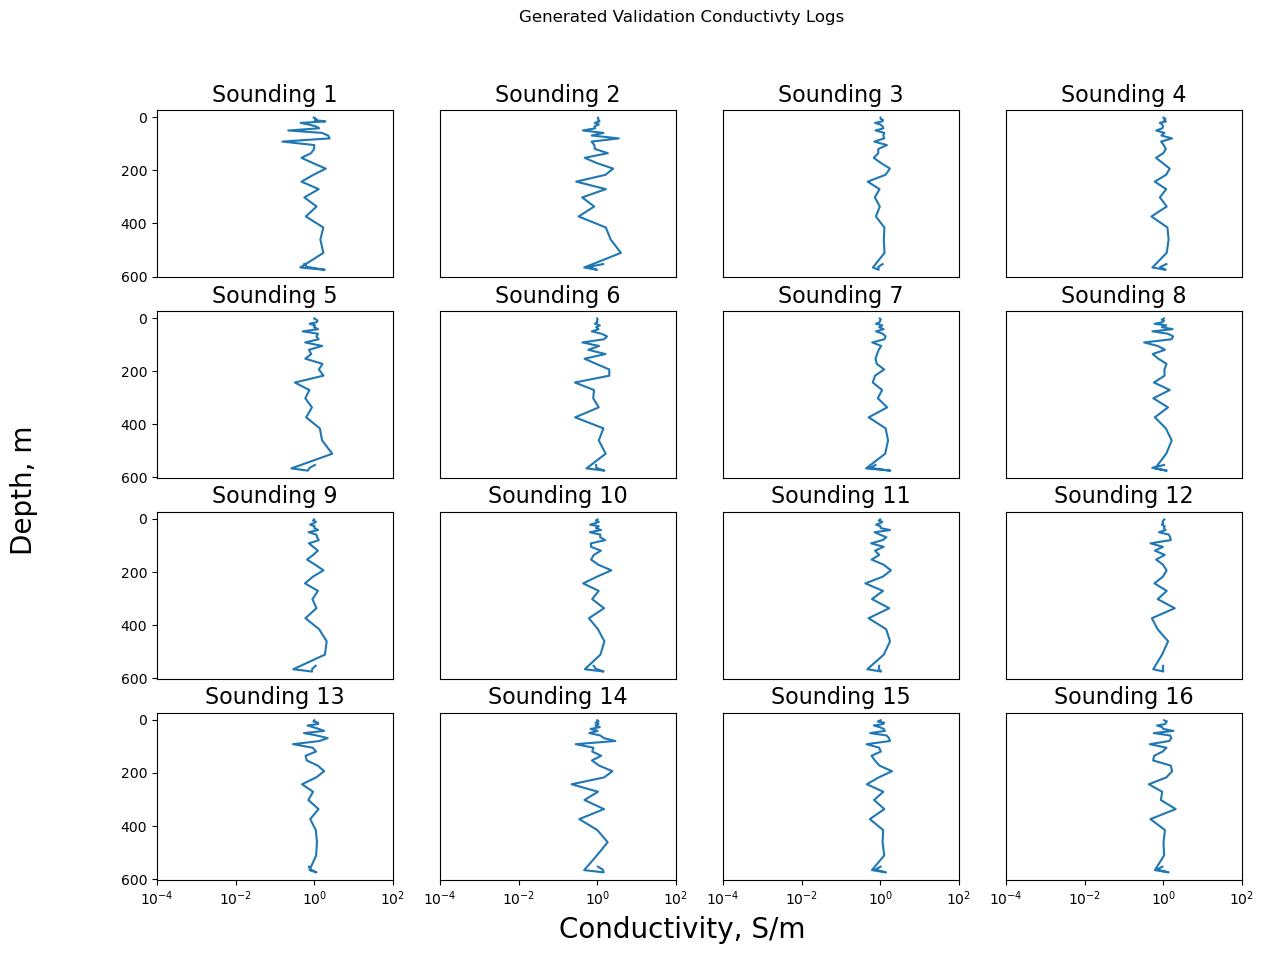

62416

<Figure size 640x480 with 0 Axes>

In [109]:
# plot a few random training models and their data
# vae.plot_complex(random_data, times=times, save2file=True, filename=run+'/training_MT_data.png')
vae.plot_logs(np.exp(network.tanhs_to_model(random_train)), depths=depths, save2file=True, 
              filename=run + '/training_models.png')

# Save starting plots
network.plot_models(save2file=True,folder=run,samples=zd_input.shape[0],
                    latent=zd_input,step=0)
# network.plot_data(save2file=True,folder=run,latent=zd_input,step=0)
# network.plot_residuals(save2file=True,folder=run,latent=zd_input,step=0)

plt.close('all')
plt.clf()
gc.collect()

In [110]:
# optimizer = tf.keras.optimizers.Adam(0.005, 0.5, clipnorm=1)
base_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
optimizer = tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)


# Train

In [111]:
epochs = 100

In [ ]:
validate_terms = []
train_terms = []
train_losses = []
ttest_losses = []
# print(len(train_dataset))
for epoch in range(1, epochs + 1):
    start_time = time.time()
#     print(train_dataset)
#     print(optimizer)
    beta = min(1.0, epoch / 50.0)
    for train_x in train_dataset:#.batch(BATCH_SIZE):
        # print(train_x)
        # tf.config.run_functions_eagerly(True)
        # z_mean, z_logvar = network.encode(train_x)
        # print(z_mean.dtype, z_logvar.dtype)
        train_loss, train_term = vae.compute_apply_gradients(network, train_x, optimizer, beta, 
                                    use_data_misfit=True)
        #train_losses.append(train_loss.numpy())
        train_terms.append([tt.numpy() for tt in train_term])
        train_losses.append(train_loss)
#         for test_x in test_dataset:
#             ttest_loss = vae.compute_losses(network, test_x)
#             terms = [loss(l).numpy() for l in ttest_loss]
#             ttest_losses.append(terms)
    end_time = time.time()

    # compute and save losses
    for val_x in validate_dataset:#.batch(BATCH_SIZE):
        val_loss, val_term = vae.compute_loss(network, val_x, beta)
        #terms = [tf.reduce_mean(l).numpy() for l in losses]
        #loss(vae.compute_reconstruction_loss(network, test_x))
    #elbo = -loss.result()
    validate_terms.append([tt.numpy() for tt in val_term])

    # CVAE print function
    print('Epoch: {}, Data misfit: {:.4}, '
          'Reconstruction: {:.4}, '
          'KL: {:.4}, '
          'Elapsed {:.4} s'.format(epoch, train_term[0], train_term[1], train_term[2],
                                #elbo,
                                end_time - start_time))

    # VAE print function
    # print('Epoch: {}, '
    #       'Reconstruction: {:.4}, '
    #       'KL: {:.4}, '
    #       'Elapsed {:.4} s'.format(epoch, train_term[0], train_term[1],
    #                             #elbo,
    #                             end_time - start_time))
    print('loss', train_loss)
    print('beta', beta)
        
    if epoch % 1e3 == 0:
        network.plot_models(save2file=True,folder=run,samples=zd_input.shape[0],
                 latent=zd_input,step=epoch)
        network.plot_data(save2file=True,folder=run,latent=zd_input,step=epoch)
        network.plot_residuals(save2file=True,folder=run,latent=zd_input,step=epoch)
        plt.close('all')
        gc.collect()

network.inference_net.save(run+'/encoder.h5')
network.generative_net.save(run+'/decoder.h5')
#np.save(run+'/optimizer_weights.npy', optimizer.load_weights())
# np.save(run+'/losses.npy', np.array(validate_terms))
# np.save(run+'/train_losses.npy', np.array(train_terms))


Epoch: 1, Data misfit: 5.677e+03, Reconstruction: 3.423e+03, KL: 0.0003247, Elapsed 236.0 s
loss tf.Tensor(9100.026, shape=(), dtype=float32)
beta 0.02
Epoch: 2, Data misfit: 4.103e+03, Reconstruction: 1.284e+03, KL: 0.004376, Elapsed 237.0 s
loss tf.Tensor(5386.893, shape=(), dtype=float32)
beta 0.04
Epoch: 3, Data misfit: 3.343e+03, Reconstruction: 1.706e+03, KL: 0.02201, Elapsed 236.0 s
loss tf.Tensor(5049.136, shape=(), dtype=float32)
beta 0.06
Epoch: 4, Data misfit: 1.866e+03, Reconstruction: 702.6, KL: 0.06119, Elapsed 234.7 s
loss tf.Tensor(2568.4685, shape=(), dtype=float32)
beta 0.08
Epoch: 5, Data misfit: 1.113e+03, Reconstruction: 465.2, KL: 0.1115, Elapsed 230.5 s
loss tf.Tensor(1578.5944, shape=(), dtype=float32)
beta 0.1
Epoch: 6, Data misfit: 1.116e+03, Reconstruction: 745.0, KL: 0.2152, Elapsed 230.3 s
loss tf.Tensor(1861.2643, shape=(), dtype=float32)
beta 0.12
Epoch: 7, Data misfit: 1.608e+03, Reconstruction: 489.5, KL: 0.3496, Elapsed 231.2 s
loss tf.Tensor(2098.0244

c:\Users\saraf\anaconda3\envs\simpeg\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [143]:
# Save weights
network.inference_net.save_weights(run + '/encoder_weights.h5')
network.generative_net.save_weights(run + '/decoder_weights.h5')

# Save optimizer
# np.save(run + '/optimizer_weights.npy', optimizer.get_weights())
import tensorflow as tf

ckpt = tf.train.Checkpoint(
    optimizer=optimizer,
    model=network
)

ckpt.save(run + "/ckpt")

# Save losses
np.save(run + '/losses.npy', np.array(validate_terms))
np.save(run + '/train_losses.npy', np.array(train_terms))

# Save metadata
np.save(run + '/training_state.npy', {
    'epoch': epoch,
    'beta': beta
})

# Load networks

In [113]:
network.inference_net = tf.keras.models.load_model(run+'/encoder.h5')
network.generative_net = tf.keras.models.load_model(run+'/decoder.h5')

In [114]:
loss_terms = np.load(run+'/losses.npy')

In [115]:
#optimizer_weights = np.load(run+'/optimizer_weights.npy', allow_pickle=True)

https://stackoverflow.com/questions/49503748/save-and-load-model-optimizer-state to train more

# Plot loss over epochs

In [116]:
plt.rcParams.update({'font.size': 18})

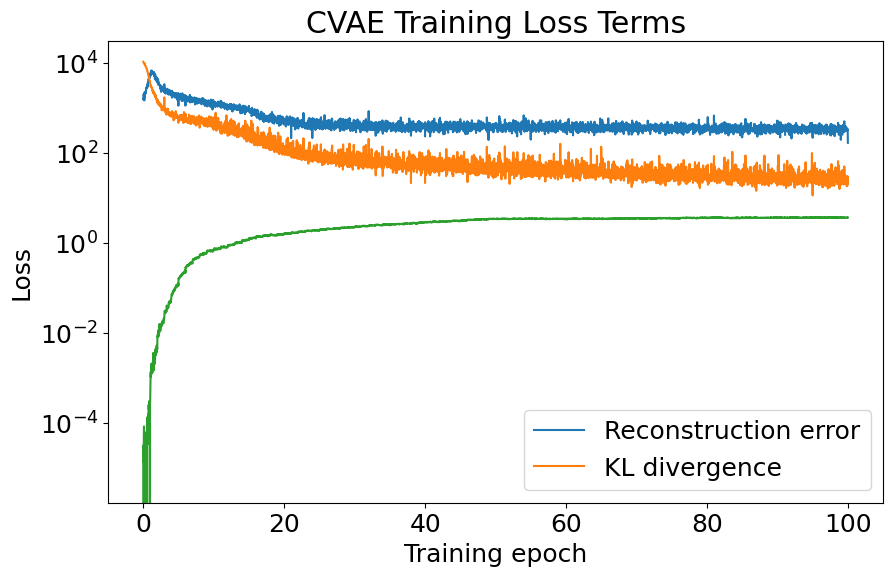

In [117]:
tt = np.array(train_terms)
batches_per_epoch = tf.data.experimental.cardinality(train_dataset).numpy()
num_batches = tt.shape[0]
plt.figure(figsize=(10,6))
plt.semilogy(np.arange(num_batches)/batches_per_epoch, tt)
plt.ylabel('Loss')
plt.xlabel('Training epoch')
plt.title("CVAE Training Loss Terms")
plt.legend(['Reconstruction error', 'KL divergence'])
plt.savefig('training_loss_'+run+'_w.png')
plt.show()

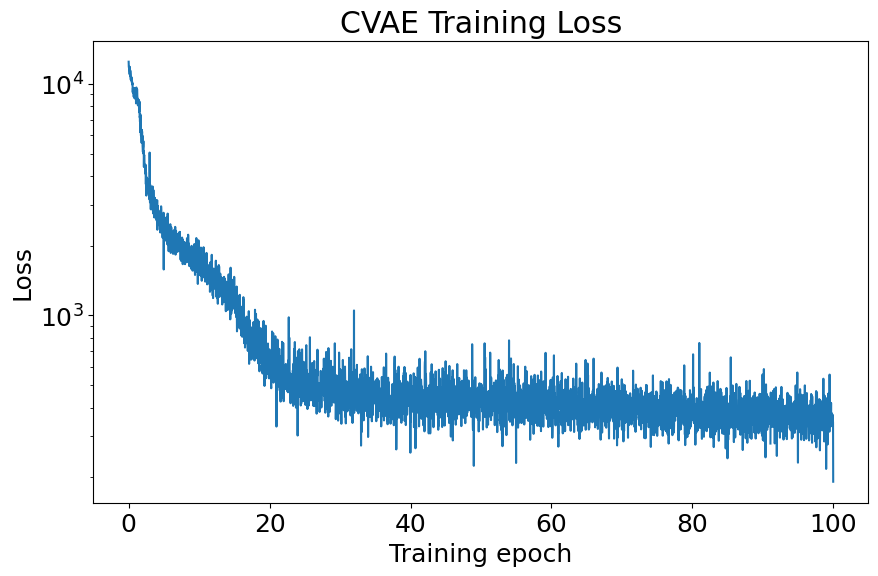

In [118]:
tl = np.array(train_losses)
batches_per_epoch = tf.data.experimental.cardinality(train_dataset).numpy()
num_batches = tt.shape[0]
plt.figure(figsize=(10,6))
plt.semilogy(np.arange(num_batches)/batches_per_epoch, tl)
plt.ylabel('Loss')
plt.xlabel('Training epoch')
plt.title("CVAE Training Loss")
# plt.legend(['Loss'])
plt.savefig('training_loss_'+run+'_w.png')
plt.show()

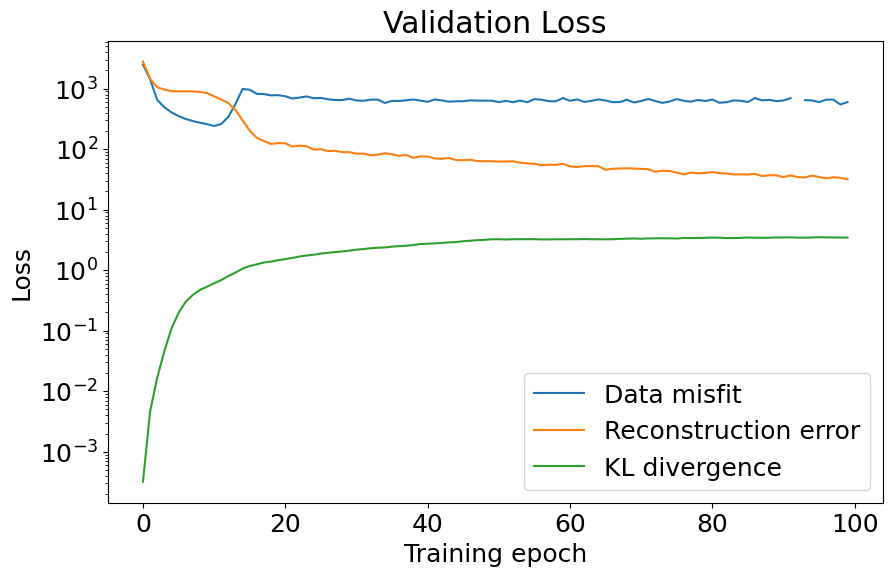

In [119]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(epochs),validate_terms)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Training epoch')
plt.title('Validation Loss')
plt.legend(['Data misfit', 'Reconstruction error', 'KL divergence'])
plt.savefig('validation_loss_'+run+'_w.png')
plt.show()

# View some tests

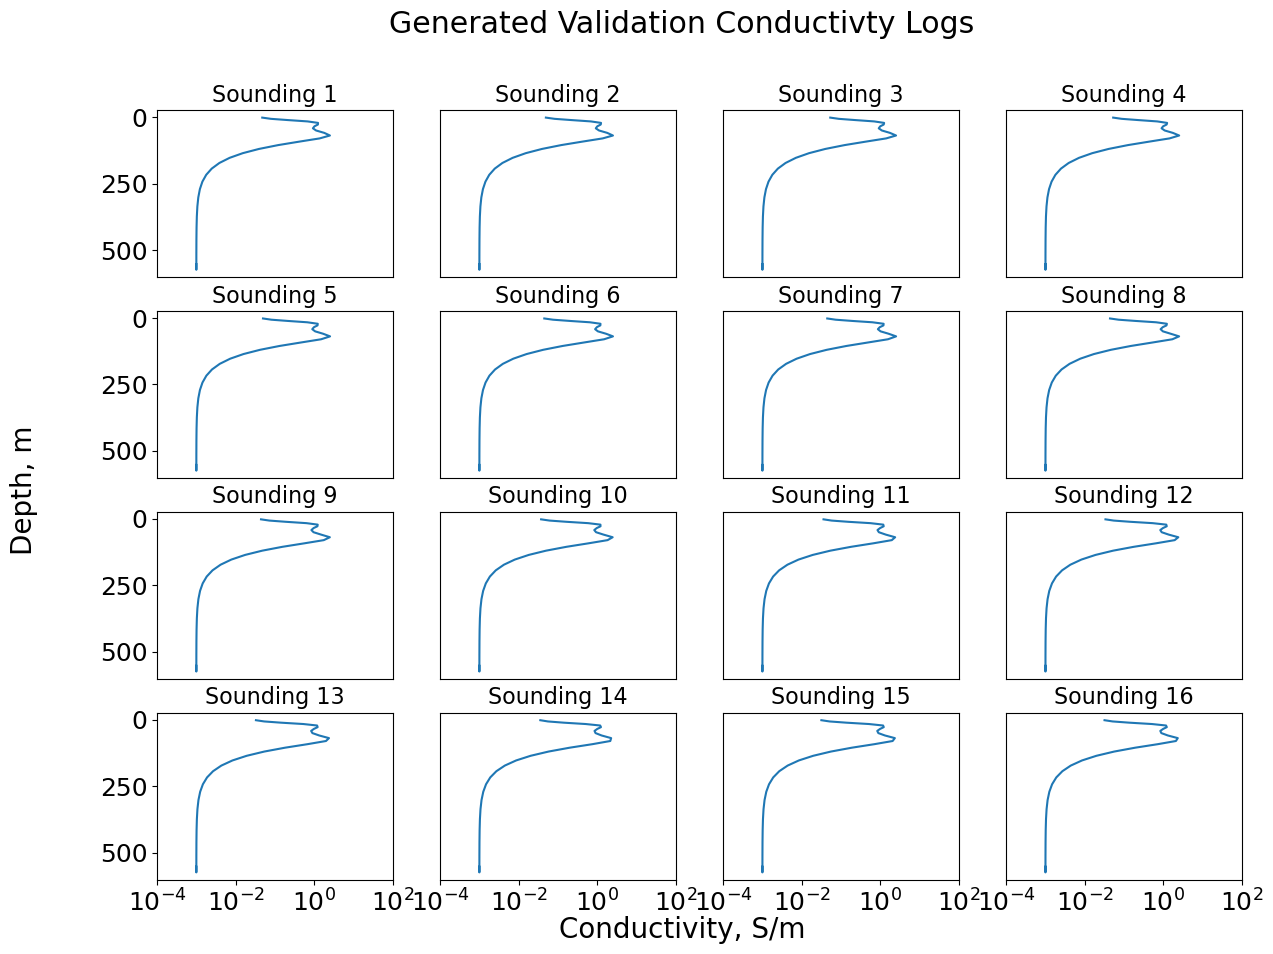

In [120]:
vae.plot_logs(np.exp(network.tanhs_to_model(x_validate[0:16])), depths=depths, step=16, save2file=False)

(16, 20)
(16, 16)


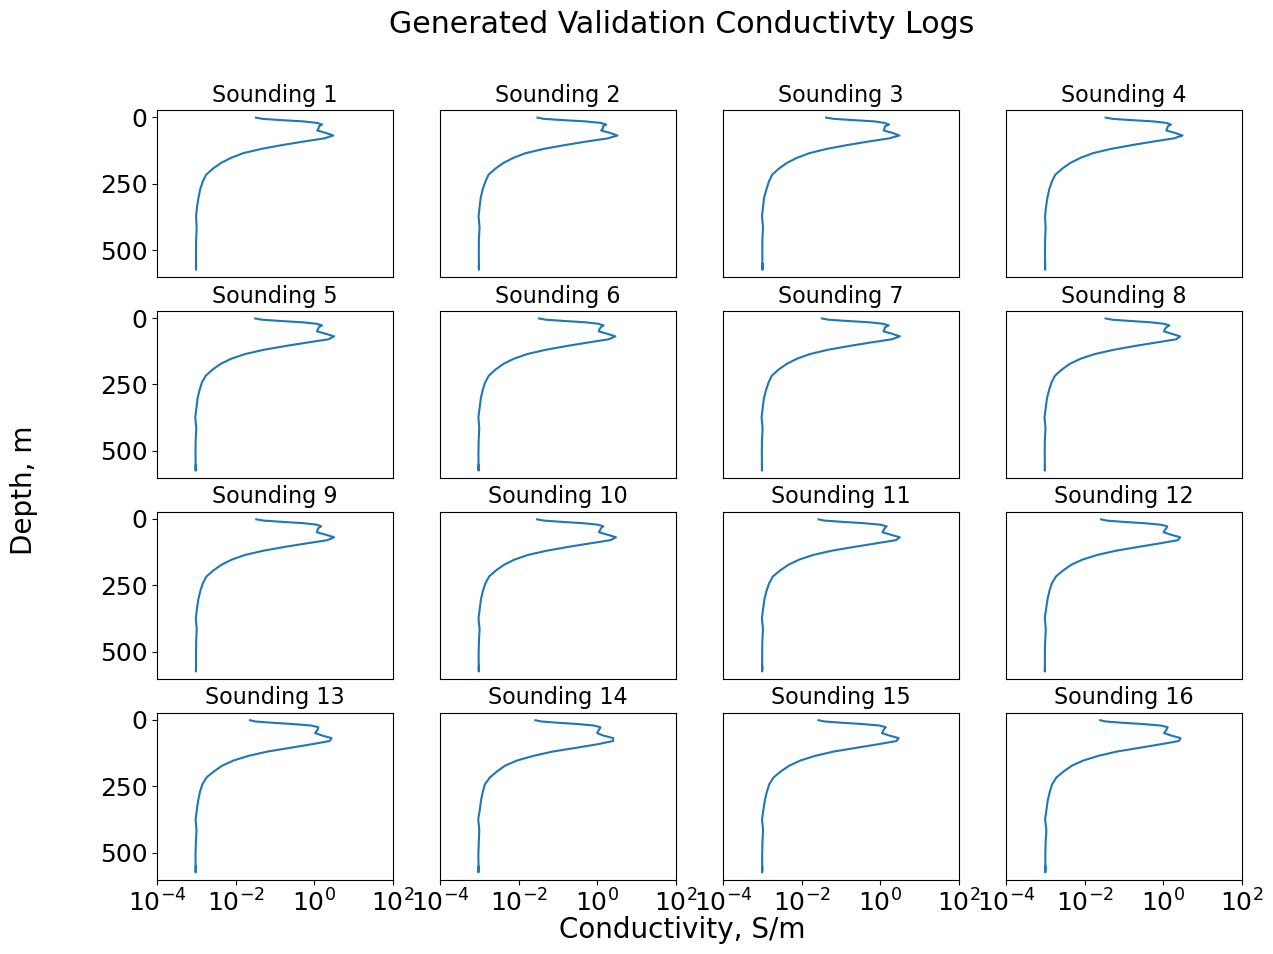

In [132]:
z_model = network.reparameterize(*network.encode(x_validate[:16]))
z_model_all = network.reparameterize(*network.encode(x_validate[:3000]))
print(np.shape(z_model))
z_data = raw_validate_data[:16]
z_data_all = raw_validate_data
print(np.shape(z_data))
zmd = tf.concat((z_model,z_data),-1)
zmd_all= tf.concat((z_model_all,z_data_all),-1)
network.plot_models(latent=zmd)

In [133]:
depth_centers = (network.depths[1:] + network.depths[:-1])/2
plot_depths = np.r_[
    depth_centers[0] - (depth_centers[1] - depth_centers[0]),
    depth_centers,
    depth_centers[-1] + depth_centers[-1] - depth_centers[-2]
]

zmd_tanhs = network.decode(zmd, apply_tanh=True)
zmd_samples = zmd_tanhs.shape[0]
zmd_tanhs = np.reshape(zmd_tanhs, (zmd_samples, network.n_model))
zmd_logs = network.tanhs_to_model(zmd_tanhs)
# zmdlogs = np.exp(zmd_logs)

true_validate = network.tanhs_to_model(x_validate[0:16])

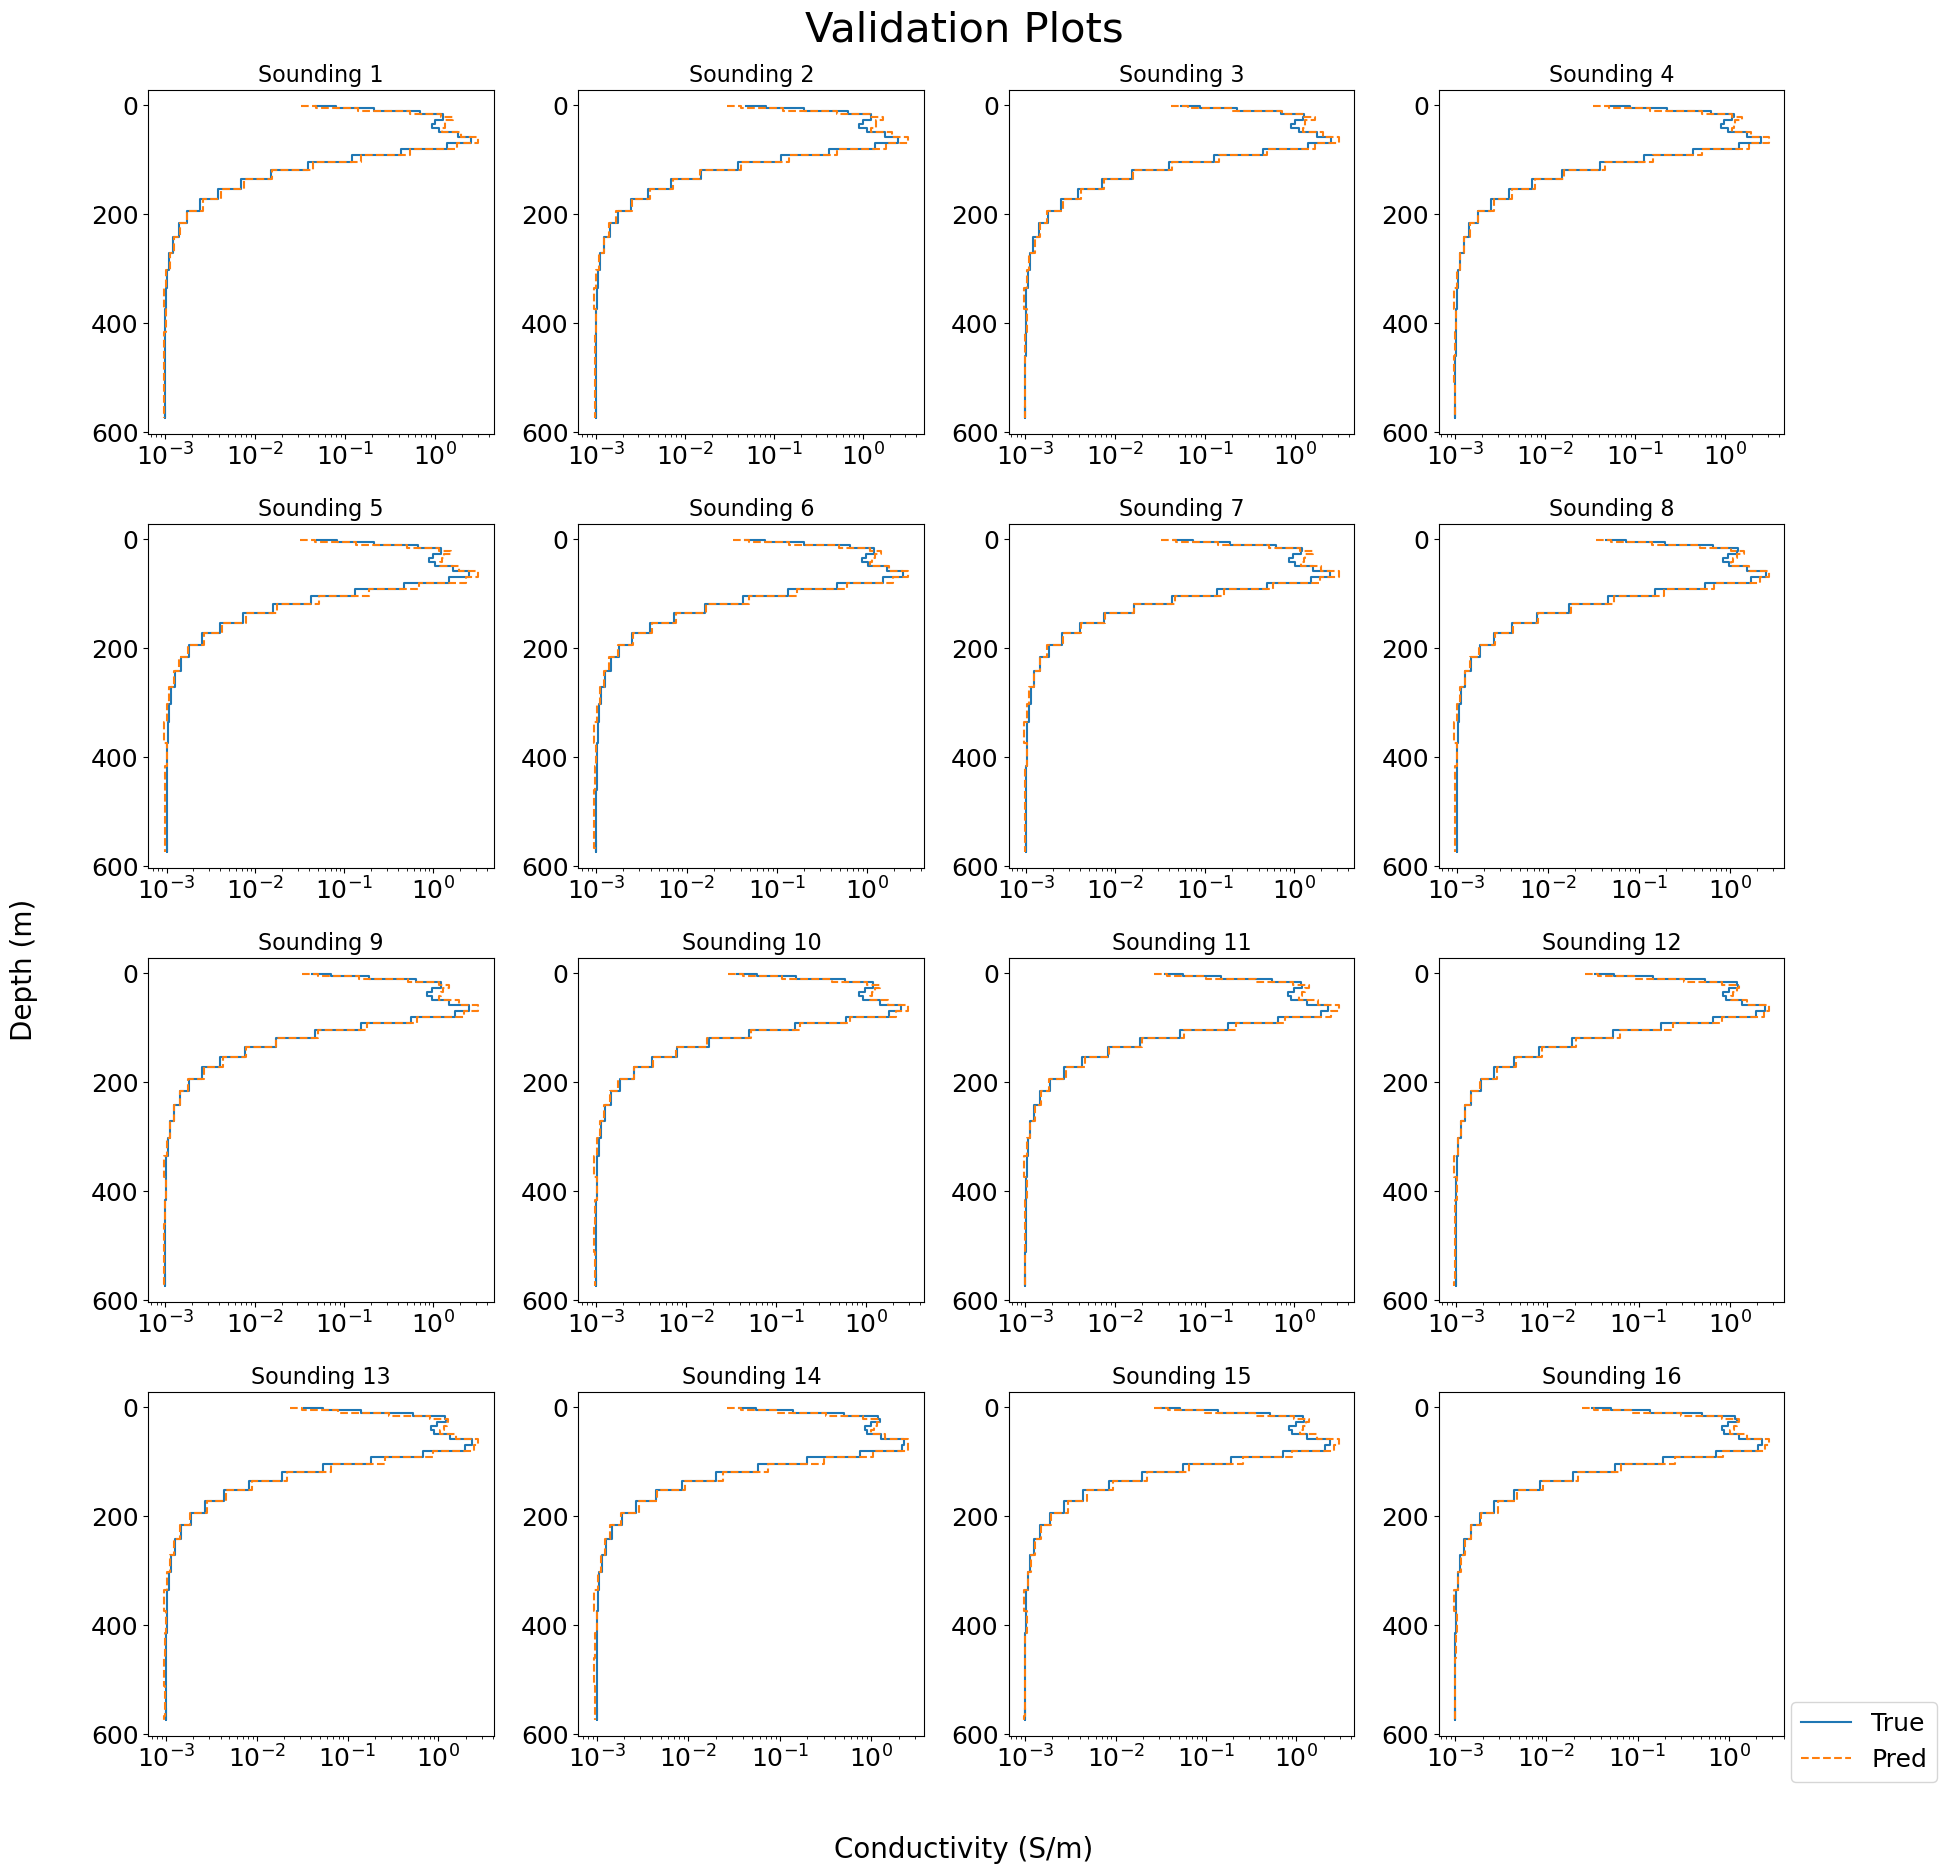

In [134]:
#Why does x2 on the predicted make it match better???
# fig = plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_validate[i], plot_depths, drawstyle='steps-post', label='True')
#     plt.plot(zmd_logs[i][:-2], plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     # plt.xlabel('Conductivity (S/m)')
#     # plt.ylabel('Depth (m)')
#     plt.suptitle('True vs Predicted Conductivity Plots',fontsize = 30)
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()

# fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
# fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
#              rotation='vertical', size=20)
# fig.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_validate[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Validation Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

In [135]:
def minmax(x): return tf.reduce_min(x), tf.reduce_max(x)

In [136]:
import numpy as np

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def r2_score(a, b):
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    return 1 - ss_res / ss_tot

In [137]:
model_rmse_v = rmse(zmd_logs, np.squeeze(true_validate))
model_mae_v = mae(zmd_logs, np.squeeze(true_validate))
model_r2_v = r2_score(zmd_logs.flatten(), np.squeeze(true_validate).flatten())

layer_rmse_v = np.sqrt(np.mean((zmd_logs- np.squeeze(true_validate)) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse_v)  # (32,)

print("Model RMSE:", model_rmse_v, np.log(np.exp(model_rmse_v)))
print("Model MAE:", model_mae_v)
print("Model R2:", model_r2_v)

Layer-wise RMSE shape: [0.32414228 0.44470509 0.4118408  0.36481134 0.20966911 0.20626051
 0.25857451 0.32958585 0.13959591 0.17100276 0.19393309 0.24328665
 0.22874542 0.26231428 0.14380449 0.08252863 0.06273015 0.06328186
 0.06162246 0.03020094 0.02424362 0.01937694 0.02360588 0.03245047
 0.07287678 0.01639416 0.02910238 0.03795837 0.02937303 0.03154176
 0.03150939 0.024327  ]
Model RMSE: 0.1926952704833408 0.19269527048334076
Model MAE: 0.13468378513408266
Model R2: 0.9960404230642173


In [138]:
tanhs = network.decode(zmd, apply_tanh=True)
minmax(tanhs)
print(tanhs)

tf.Tensor(
[[[-0.26717633]
  [-0.2375885 ]
  [-0.15414706]
  [-0.04893444]
  [ 0.01308514]
  [ 0.03601024]
  [ 0.0213373 ]
  [ 0.02029141]
  [ 0.01382026]
  [ 0.05285511]
  [ 0.08721446]
  [ 0.0451047 ]
  [-0.05053979]
  [-0.14731932]
  [-0.24362299]
  [-0.3250445 ]
  [-0.38100895]
  [-0.42680988]
  [-0.46391848]
  [-0.49530643]
  [-0.5105549 ]
  [-0.5221916 ]
  [-0.5296833 ]
  [-0.5366649 ]
  [-0.54104227]
  [-0.5384437 ]
  [-0.5407515 ]
  [-0.5414681 ]
  [-0.54140687]
  [-0.541374  ]
  [-0.5416029 ]
  [-0.5409239 ]]

 [[-0.2737191 ]
  [-0.24573565]
  [-0.16084932]
  [-0.05296284]
  [ 0.01474678]
  [ 0.04075293]
  [ 0.02619258]
  [ 0.02647676]
  [ 0.01733294]
  [ 0.0584077 ]
  [ 0.09246422]
  [ 0.04727526]
  [-0.05131541]
  [-0.148403  ]
  [-0.24632742]
  [-0.328341  ]
  [-0.38386136]
  [-0.43013135]
  [-0.4664683 ]
  [-0.49846444]
  [-0.51246494]
  [-0.5244682 ]
  [-0.5334678 ]
  [-0.5388007 ]
  [-0.54349077]
  [-0.53904814]
  [-0.542158  ]
  [-0.5424965 ]
  [-0.54205716]
  [-0.54174

In [139]:
minmax(x_test[0:16])

(<tf.Tensor: shape=(), dtype=float64, numpy=-0.5399266299885006>,
 <tf.Tensor: shape=(), dtype=float64, numpy=0.03254183984457575>)

(16, 36)


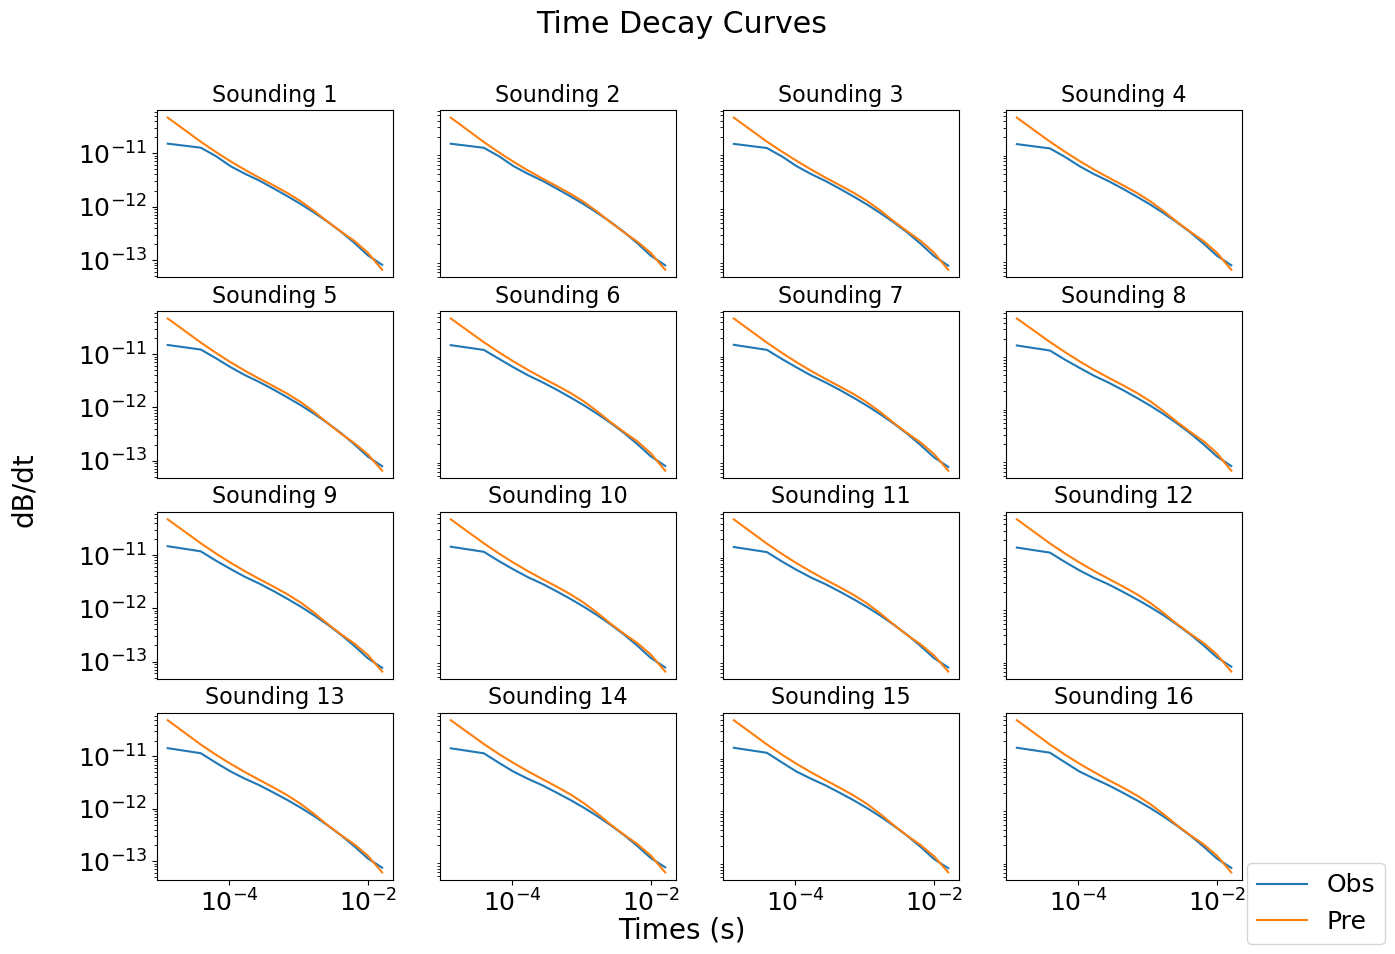

In [140]:
print(zmd.shape)
network.plot_data(latent=zmd)

# d_obs is from validation seta

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-3.11678114e-11 -3.67014578e-12 -1.68648342e-12 -1.34648109e-12
  -7.48600834e-13 -3.94884863e-13 -3.02396779e-13 -2.30284325e-13
  -1.40283401e-13 -5.49029680e-14 -2.00848452e-15 -2.27479168e-15
  -1.85874265e-14 -1.49297485e-14 -1.56636382e-14 -1.56977635e-14]
 [-3.07479597e-11 -3.49345639e-12 -1.52016854e-12 -1.16745155e-12
  -6.32657988e-13 -3.08405645e-13 -2.32875351e-13 -1.82076576e-13
  -1.10913232e-13 -3.90615275e-14 -7.80538828e-15 -5.29621919e-15
  -1.47069314e-14 -1.46501599e-14 -1.41176675e-14 -1.41515014e-14]
 [-3.08098096e-11 -3.92707308e-12 -1.97640515e-12 -1.47592572e-12
  -8.71957888e-13 -4.72910556e-13 -3.47463594e-13 -2.70955784e-13
  -1.78530584e-13 -8.74603124e-14 -2.53189397e-14 -1.64868932e-14
  -2.69895190e-14 -1.96077285e-14 -1.30184221e-14 -1.30523102e-14]
 [-3.15731816e-11 -4.17375769e-12 -2.06448660e-12 -1.42407744e-12
  -8.66649634e-13 -4.88654256e-13 -3.5456988

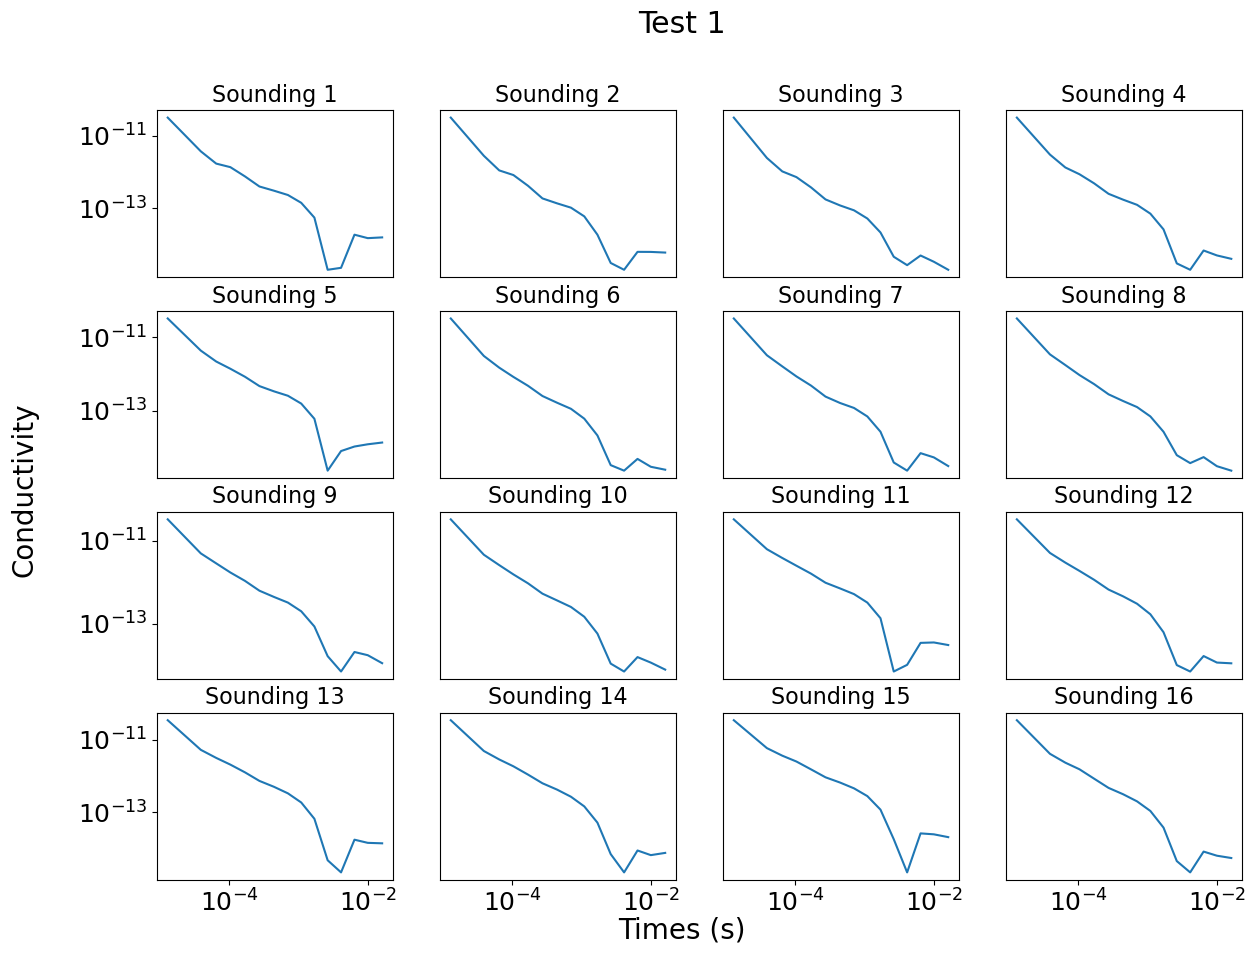

In [141]:
network.plot_residuals(latent=zmd, weighted=False, step=15)

# Randomize latent; does data still fit?

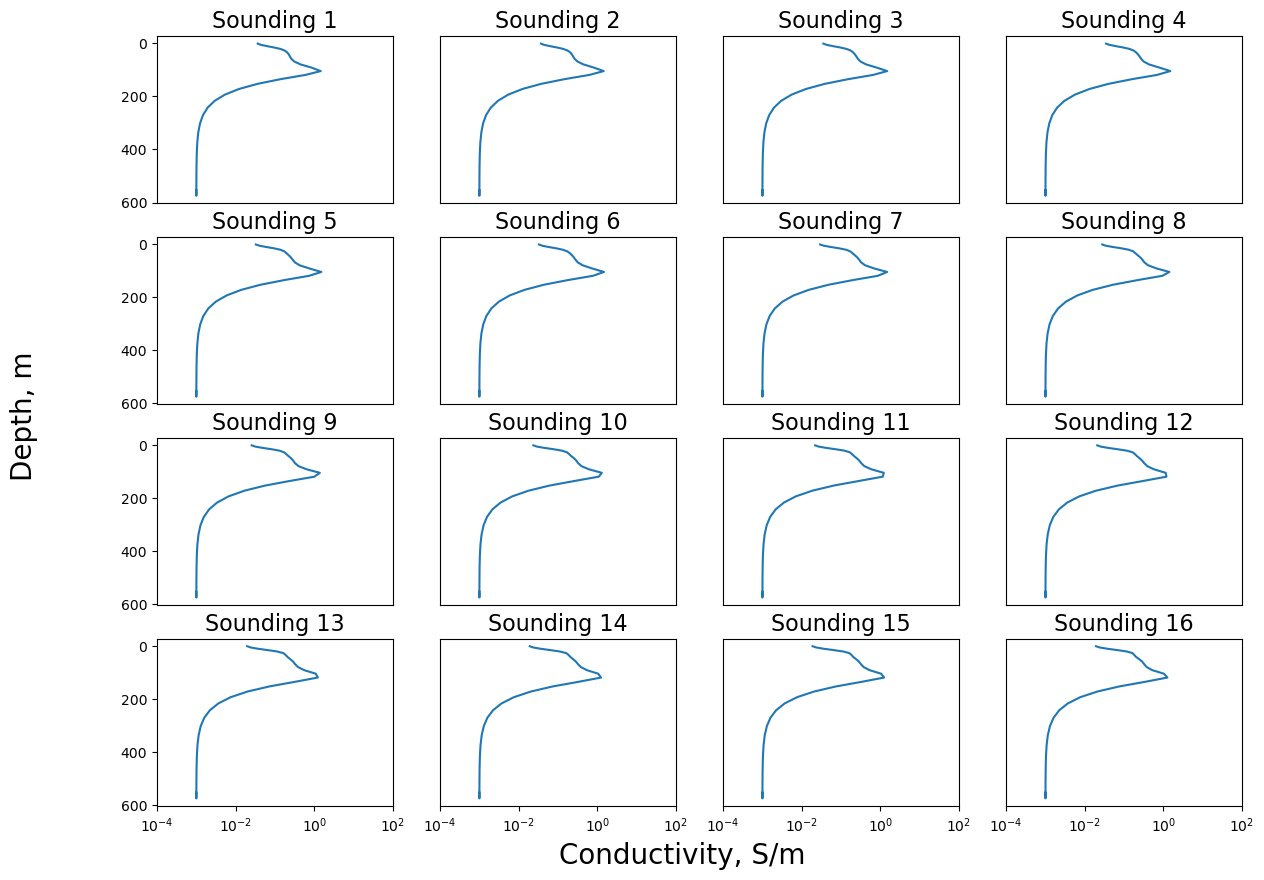

In [ ]:
vae.plot_logs(np.exp(network.tanhs_to_model(x_test[0   :16])), depths=depths)

In [ ]:
print(x_test[0:1,:,0].shape)
print(z_data[0:1].shape)

(1, 32)
(1, 16)


In [ ]:
data0 = tf.tile(z_data[0:1],[16,1])
# print(latent_input)
data0 = tf.cast(data0, tf.float32)
# print(data0)
zmd2 = tf.concat((latent_input,data0),-1)
# print(zmd2)

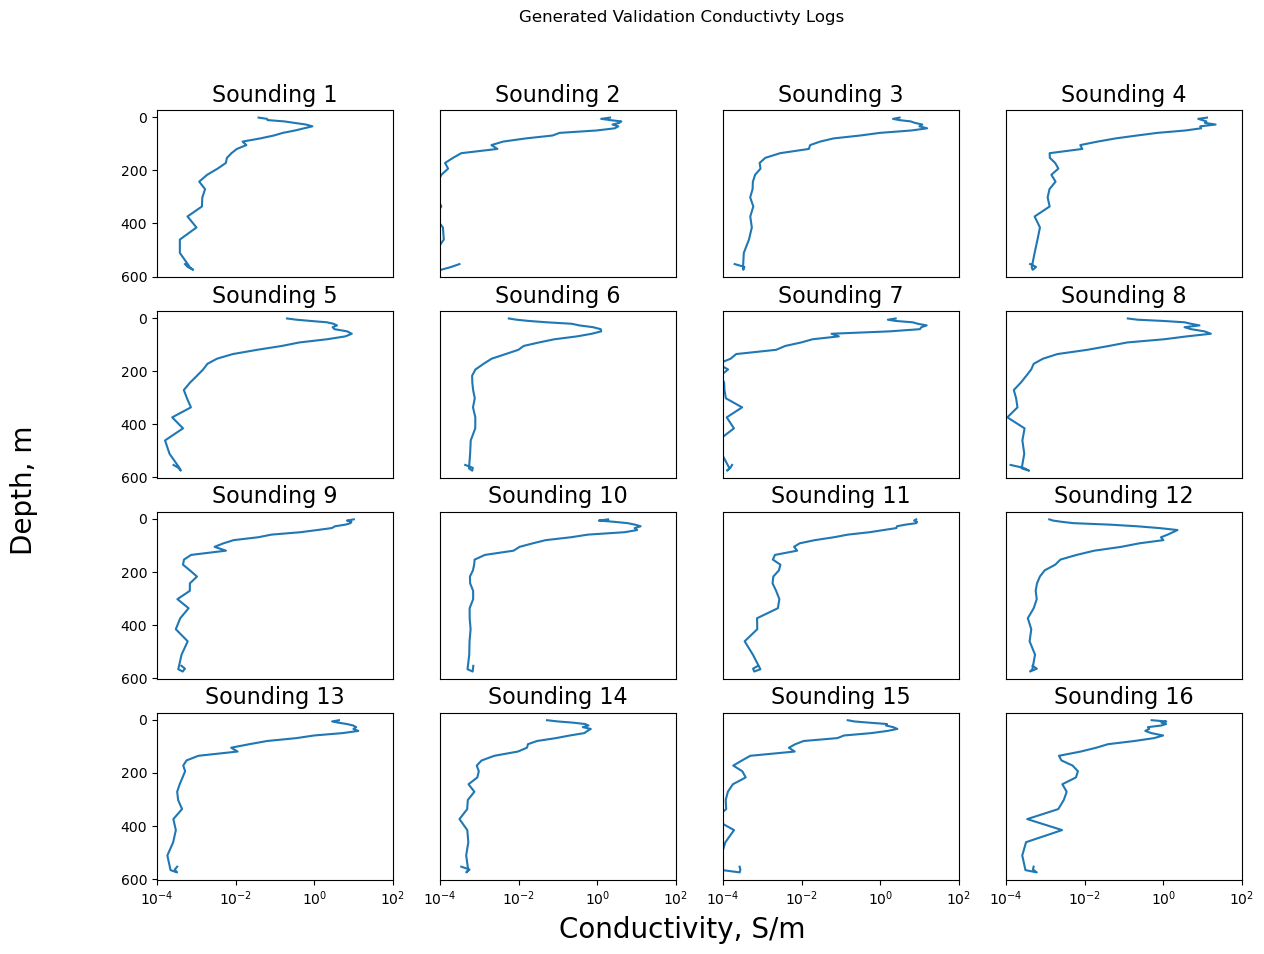

In [ ]:
network.plot_models(latent=zmd2)

In [ ]:
zmd2_tanhs = network.decode(zmd2, apply_tanh=True)
zmd2_samples = zmd2_tanhs.shape[0]
zmd2_tanhs = np.reshape(zmd2_tanhs, (zmd2_samples, network.n_model))
zmd2_logs = network.tanhs_to_model(zmd2_tanhs)
print(np.shape(zmd2_logs))
# zmd2 = (10**zmd2_logs)-1


# true_test = tf.tile(x_test[0:1,:,0],[16,1])
# true_test = tf.cast(true_test, tf.float32)
true_test1 = network.tanhs_to_model(x_test[0   :16])
true_test1_all = network.tanhs_to_model(x_test)
# true_test1 = (10**true_test1)-1
print(true_test1)

(16, 32)
[[[-3.31088202]
  [-3.12918755]
  [-2.79267944]
  [-2.37157961]
  [-1.98730804]
  [-1.7325936 ]
  [-1.5877366 ]
  [-1.49473695]
  [-1.42336797]
  [-1.33915432]
  [-1.17041972]
  [-0.80862201]
  [-0.1648099 ]
  [ 0.3823309 ]
  [-0.52120413]
  [-1.97625338]
  [-3.31956809]
  [-4.40550654]
  [-5.23106628]
  [-5.82970427]
  [-6.24452518]
  [-6.51871973]
  [-6.69096708]
  [-6.79341907]
  [-6.85087224]
  [-6.88111724]
  [-6.89600755]
  [-6.90283938]
  [-6.90572833]
  [-6.90675378]
  [-6.90603365]
  [-6.90637143]]

 [[-3.2988651 ]
  [-3.12247193]
  [-2.79401193]
  [-2.37975246]
  [-1.99775686]
  [-1.74067765]
  [-1.59130825]
  [-1.49309547]
  [-1.41607792]
  [-1.32819339]
  [-1.16155401]
  [-0.81343432]
  [-0.20035702]
  [ 0.37471926]
  [-0.46860285]
  [-1.92662501]
  [-3.28337915]
  [-4.38100636]
  [-5.21524209]
  [-5.81994917]
  [-6.23882395]
  [-6.51559631]
  [-6.68939354]
  [-6.79271467]
  [-6.8506172 ]
  [-6.88106856]
  [-6.89603918]
  [-6.90289113]
  [-6.90578223]
  [-6.9068167

In [ ]:
zmd2_logs.shape

(16, 32)

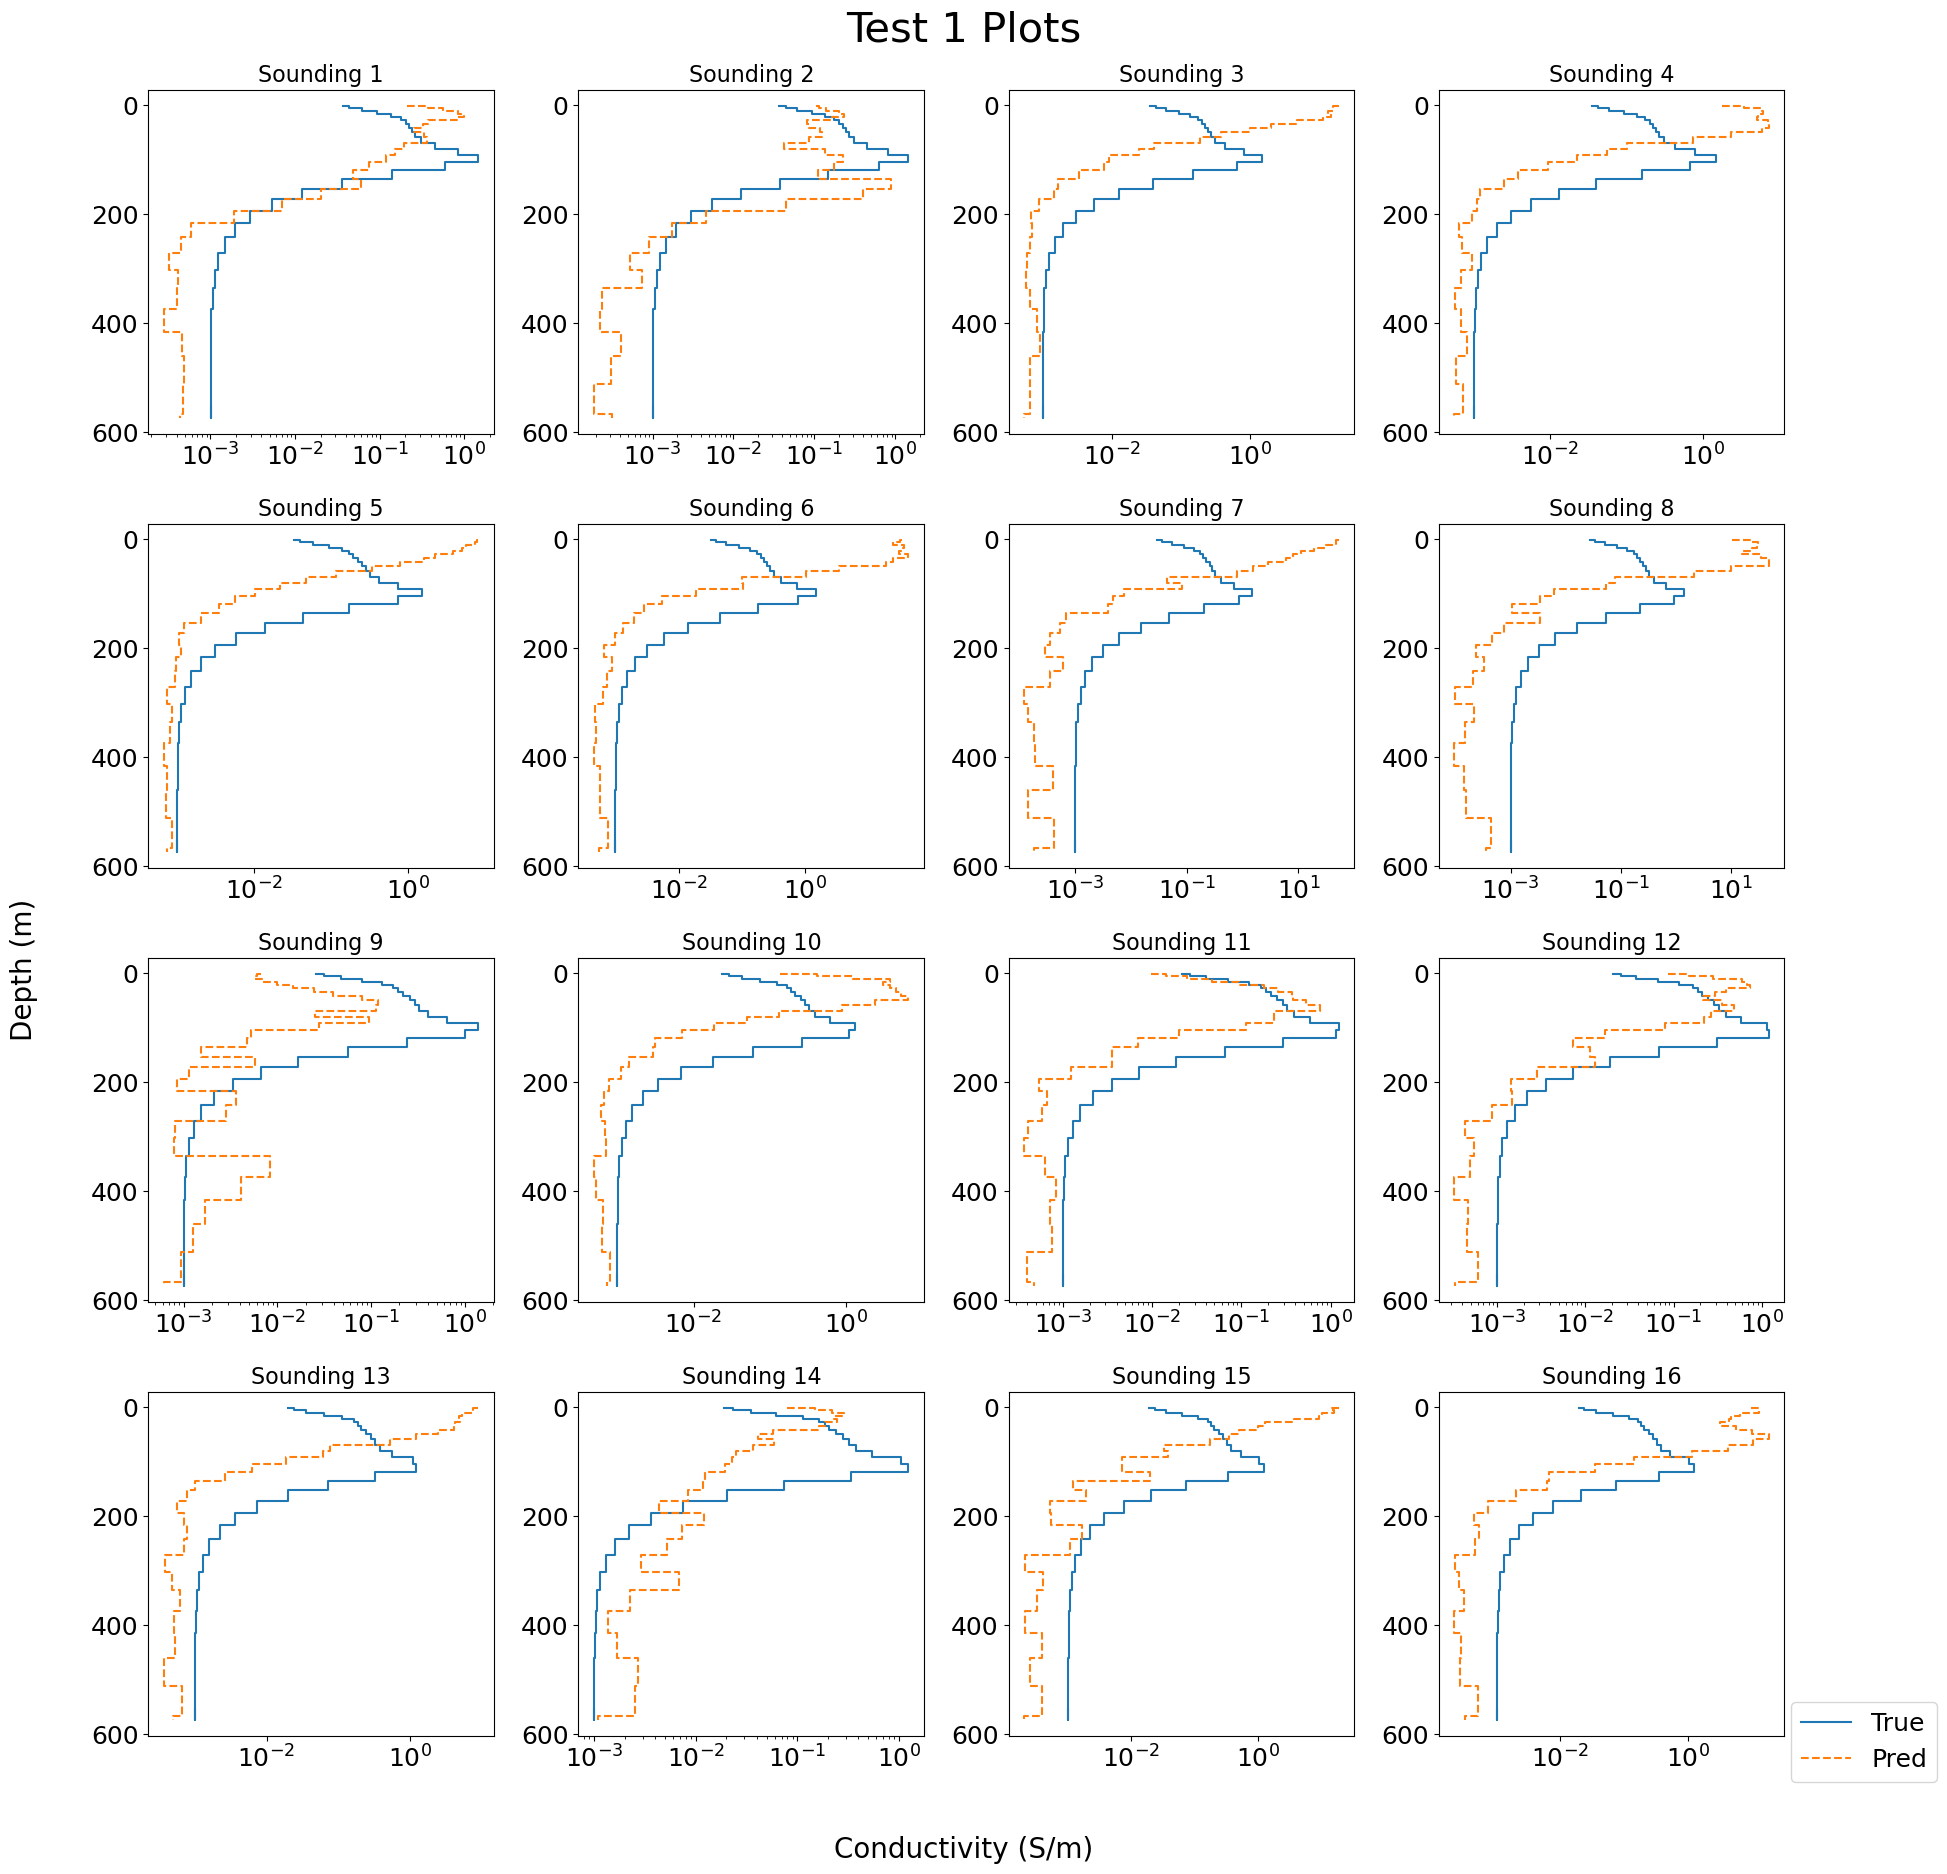

In [ ]:
# plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_test1[i], plot_depths, drawstyle='steps-post', label='True')
#     plt.plot(np.exp(zmd2_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     plt.xscale('log')
#     # plt.plot(zmd2_logs[i], plot_depths, label='Pred_logs', linestyle='--')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_test1[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd2_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Test 1 Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

In [ ]:
#apply np.exp and log to zmd_logs and true_test to put it in same range as plots
model_rmse = rmse(zmd2_logs, np.squeeze(true_test1))
model_mae = mae(zmd2_logs, np.squeeze(true_test1))
model_r2 = r2_score(zmd2_logs.flatten(), np.squeeze(true_test1).flatten())

layer_rmse = np.sqrt(np.mean((zmd2_logs- np.squeeze(true_test1)) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse)  # (32,)

print("Model RMSE:", model_rmse)
print("Model MAE:", model_mae)
print("Model R2:", model_r2)

Layer-wise RMSE shape: [4.76307817 4.72454501 4.5370242  4.06717254 3.55794493 3.12677226
 2.9211283  2.73765762 2.49859438 1.86853505 1.32114376 1.89604178
 2.32438866 4.03939172 4.49353015 3.77646986 3.07465486 2.33406927
 1.96504916 1.6008604  1.05561176 1.00358257 1.31825018 1.09441407
 1.1467471  1.192712   0.83277159 1.02547004 0.7396641  0.92162038
 0.90263422 0.68687149]
Model RMSE: 2.653972527014905
Model MAE: 2.046896932288649
Model R2: 0.5021311791389729


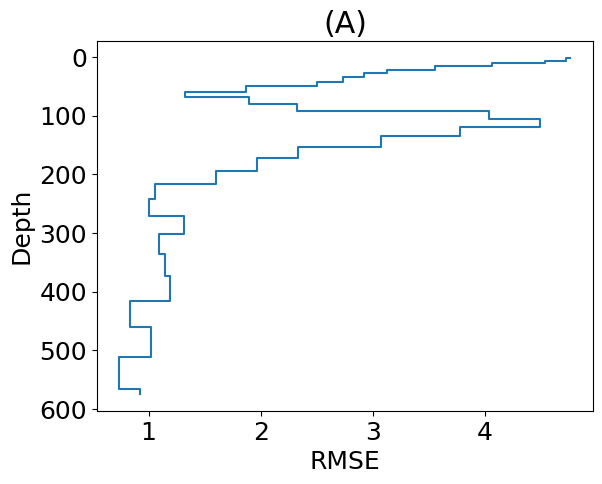

In [ ]:
plt.plot(layer_rmse[:-2],plot_depths[:-2], drawstyle='steps-post')
plt.gca().invert_yaxis()
plt.title('(A)')
plt.xlabel('RMSE')
plt.ylabel('Depth')
plt.show()

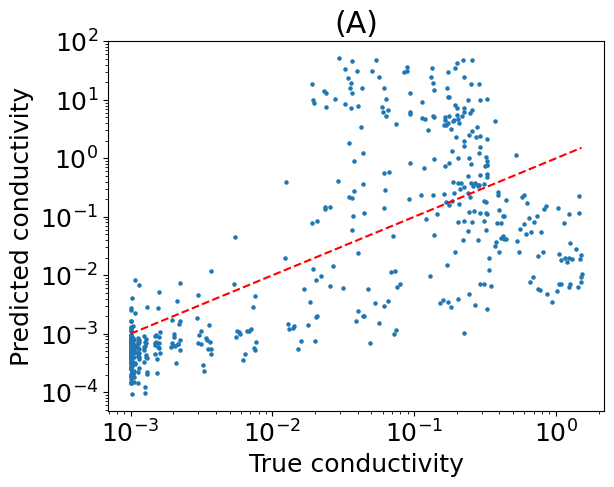

In [ ]:
true_test1_flat = true_test1.flatten()
pred_test1_flat = zmd2_logs.flatten()
plt.scatter(np.exp(true_test1_flat[:-2]), np.exp(pred_test1_flat[:-2]), s=5)

plt.plot([np.exp(true_test1.min()), np.exp(true_test1.max())],
         [np.exp(true_test1.min()), np.exp(true_test1.max())],
         'r--')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("True conductivity")
plt.ylabel("Predicted conductivity")

plt.title('(A)')

# plt.legend()
plt.show()

In [ ]:
true_models2 = np.squeeze(true_test1)

mean_cond2 = np.mean(zmd2_logs,axis=0)
# mean_true_cond2 = np.mean(true_models2, axis=0)
std_cond = np.std(zmd2_logs,axis=0)
# print(std_cond)
# print(mean_cond2)

# mae2_log = mean_absolute_error(true_models2, zmd2_logs)
# mse2_log = mean_squared_error(true_models2, zmd2_logs)

# mae2_linear = mean_absolute_error(np.exp(true_models2), np.exp(zmd2_logs))
# mse2_linear = mean_squared_error(np.exp(true_models2), np.exp(zmd2_logs))

# percent_error2 = mean_absolute_percentage_error(np.exp(true_models2), np.exp(zmd2_logs))

# print(mae2_log, mse2_log)
# print(mae2_linear, mse2_linear)
# print(percent_error2)

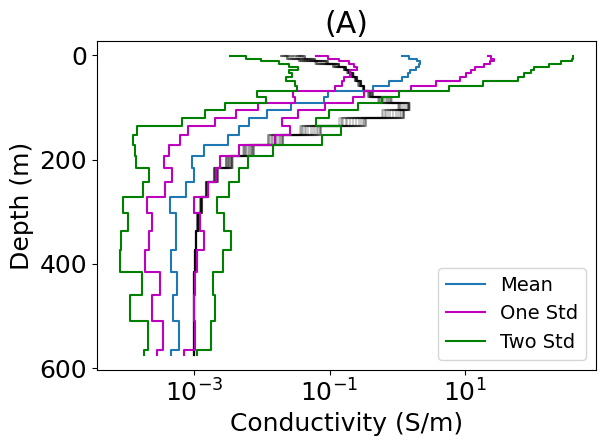

In [ ]:
fig, ax = plt.subplots()
for log in true_models2:
    ax.plot(np.exp(log[:-2]), plot_depths[:-2],drawstyle='steps-post', c='k', alpha=0.2)
ax.plot(np.exp(mean_cond2[:-2]), plot_depths[:-2], drawstyle='steps-post',label='Mean')
ax.plot(np.exp(mean_cond2[:-2]+std_cond[:-2]),plot_depths[:-2], drawstyle='steps-post', c='m', label="One Std")
ax.plot(np.exp(mean_cond2[:-2]-std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='m')
ax.plot(np.exp(mean_cond2[:-2]+2*std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g', label= 'Two Std') # type: ignore
ax.plot(np.exp(mean_cond2[:-2]-2*std_cond[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g')
# ax.plot(true_test1[1],plot_depths, c='orange', label = 'True Mean')
ax.invert_yaxis()
ax.axes.set_xlabel("Conductivity (S/m)")
ax.axes.set_ylabel("Depth (m)")
ax.axes.set_xscale('log')
# ax.axes.set_xlim(1e-1, 1e3)
ax.axes.set_title('(A)')
ax.axes.legend(fontsize=14)

plt.tight_layout()
plt.savefig('Preliminary_generated_plots_mean&2std.jpg')
plt.show()



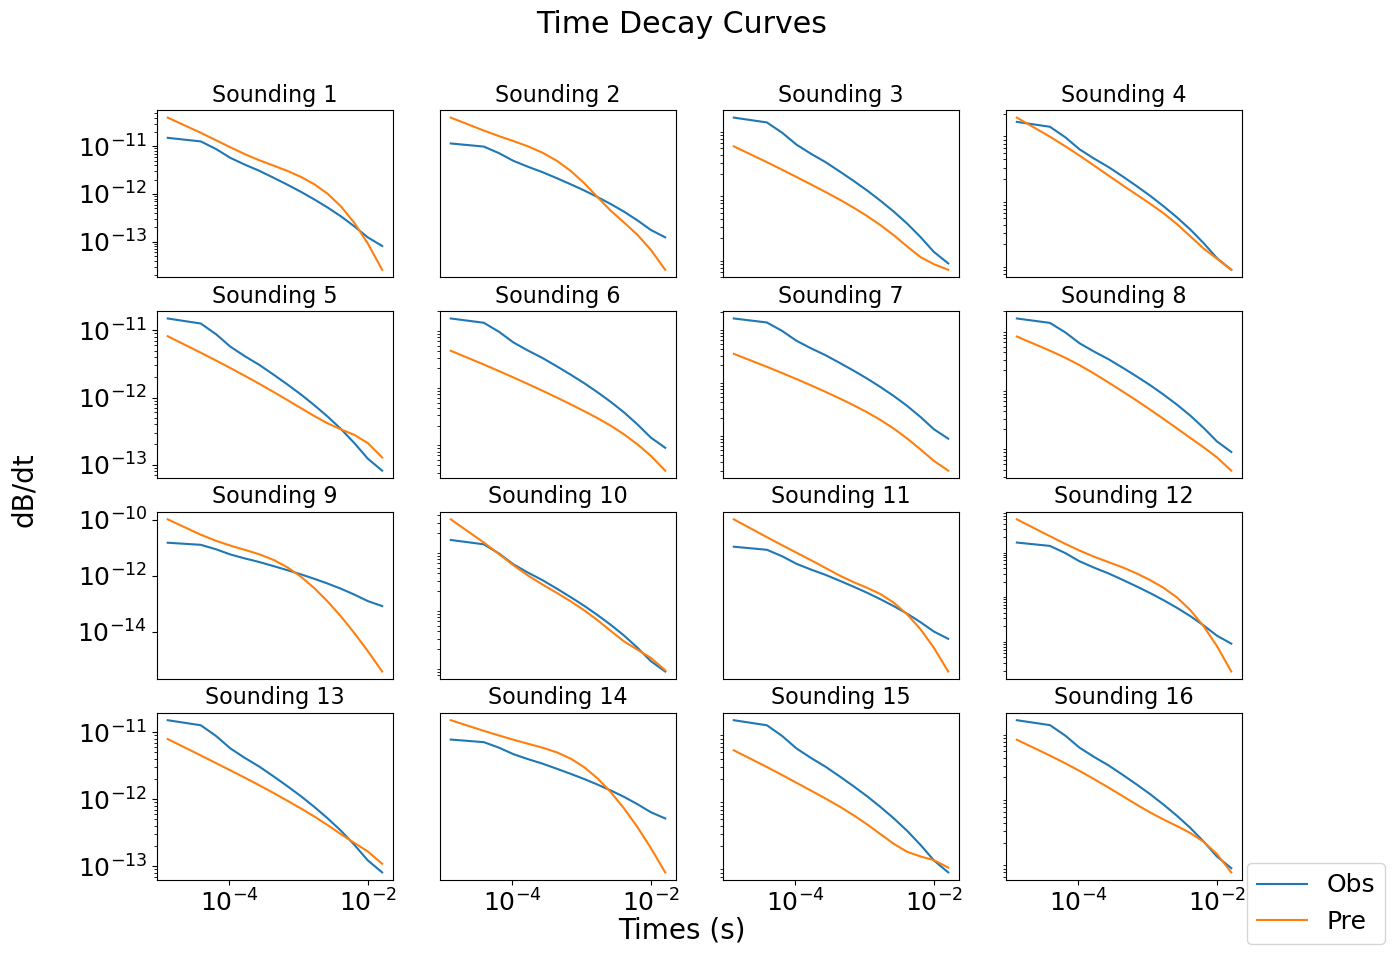

In [ ]:
network.plot_data(latent=zmd2)

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-5.96492324e-14 -8.26283825e-14 -1.60945557e-13 -2.03752434e-13
  -1.73995177e-13 -1.33071004e-13 -9.67296718e-14 -5.11279624e-14
  -6.21347922e-15 -2.69468286e-14 -3.92821084e-14 -2.84400189e-14
  -7.44082869e-15 -8.23904882e-15 -1.81905492e-14 -2.11312528e-14]
 [-1.15754316e-13 -2.30661519e-13 -4.81899676e-13 -6.15973906e-13
  -5.58750908e-13 -3.90724128e-13 -1.96749721e-13 -5.87481046e-14
  -2.92557853e-15 -4.99172629e-17 -1.28969008e-14 -2.10436239e-14
  -2.31599950e-14 -2.19043940e-14 -2.22249621e-14 -2.58142794e-14]
 [-2.31643436e-14 -1.21898355e-13 -2.24010738e-13 -2.10502880e-13
  -1.76413260e-13 -1.31673779e-13 -7.67012186e-14 -3.30648899e-14
  -3.53559726e-15 -1.45202725e-14 -2.37605261e-14 -2.59390796e-14
  -2.14347718e-14 -1.16697499e-14 -5.43583902e-15 -6.32194263e-15]
 [-5.85225143e-15 -4.73961046e-14 -8.31526552e-14 -6.10280937e-14
  -5.74407465e-14 -5.21636059e-14 -3.2335425

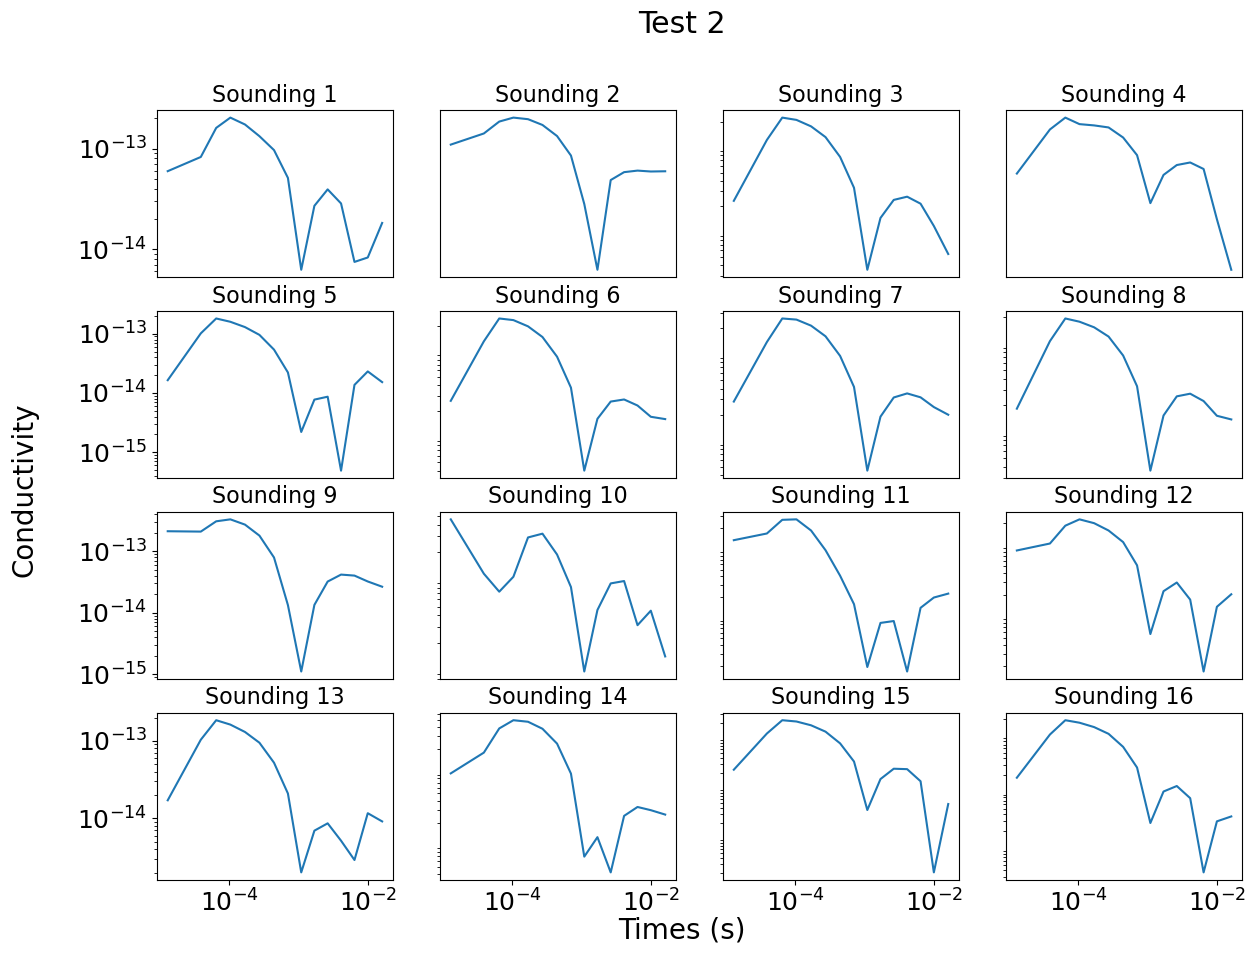

In [ ]:
network.plot_residuals(latent=zmd2, weighted=True, step=14)

# Sample latent & different data soundings

In [ ]:
# Plot true models for comparisons - need models for line 94 and adjust plot_logs to show true models too

data_batch = raw_test_data94[0:16]
latent_dim = 20  # known from model
latent_input = tf.random.normal((16, latent_dim))

In [ ]:
zmd3 = tf.concat(((latent_input), data_batch), -1)
print(zmd3.shape)

(16, 36)


In [ ]:
zmd3_tanhs = network.decode(zmd3, apply_tanh=True)
zmd3_samples = zmd3_tanhs.shape[0]
zmd3_tanhs = np.reshape(zmd3_tanhs, (zmd3_samples, network.n_model))
zmd3_logs = network.tanhs_to_model(zmd3_tanhs)
# zmd3_exp = (10**zmd3_logs)

In [ ]:
true_models = x_test94[0:2000]
true_logs = network.tanhs_to_model(true_models)
true_models = np.exp(true_logs)
# print(true_logs[100])

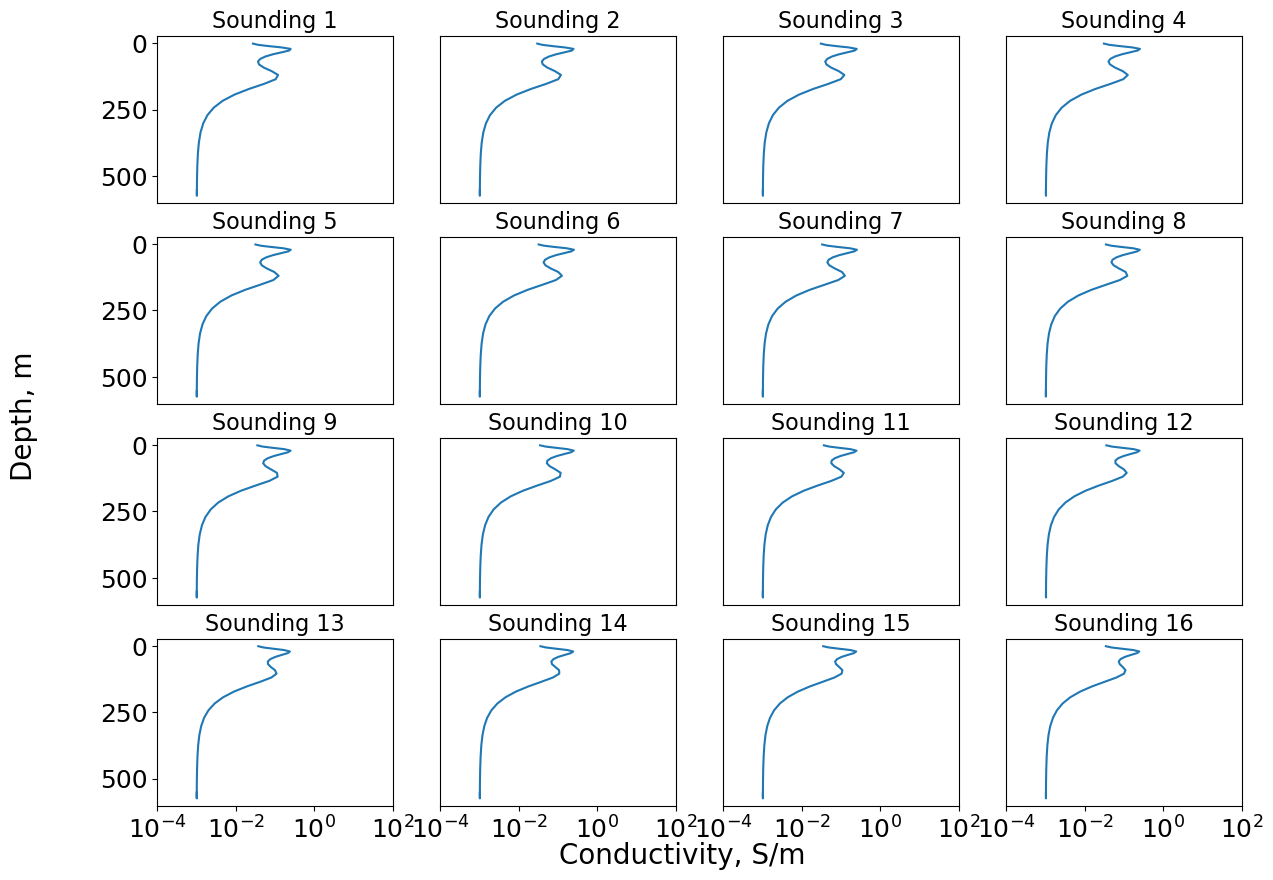

In [ ]:
vae.plot_logs(true_models[0:16], depths=depths)

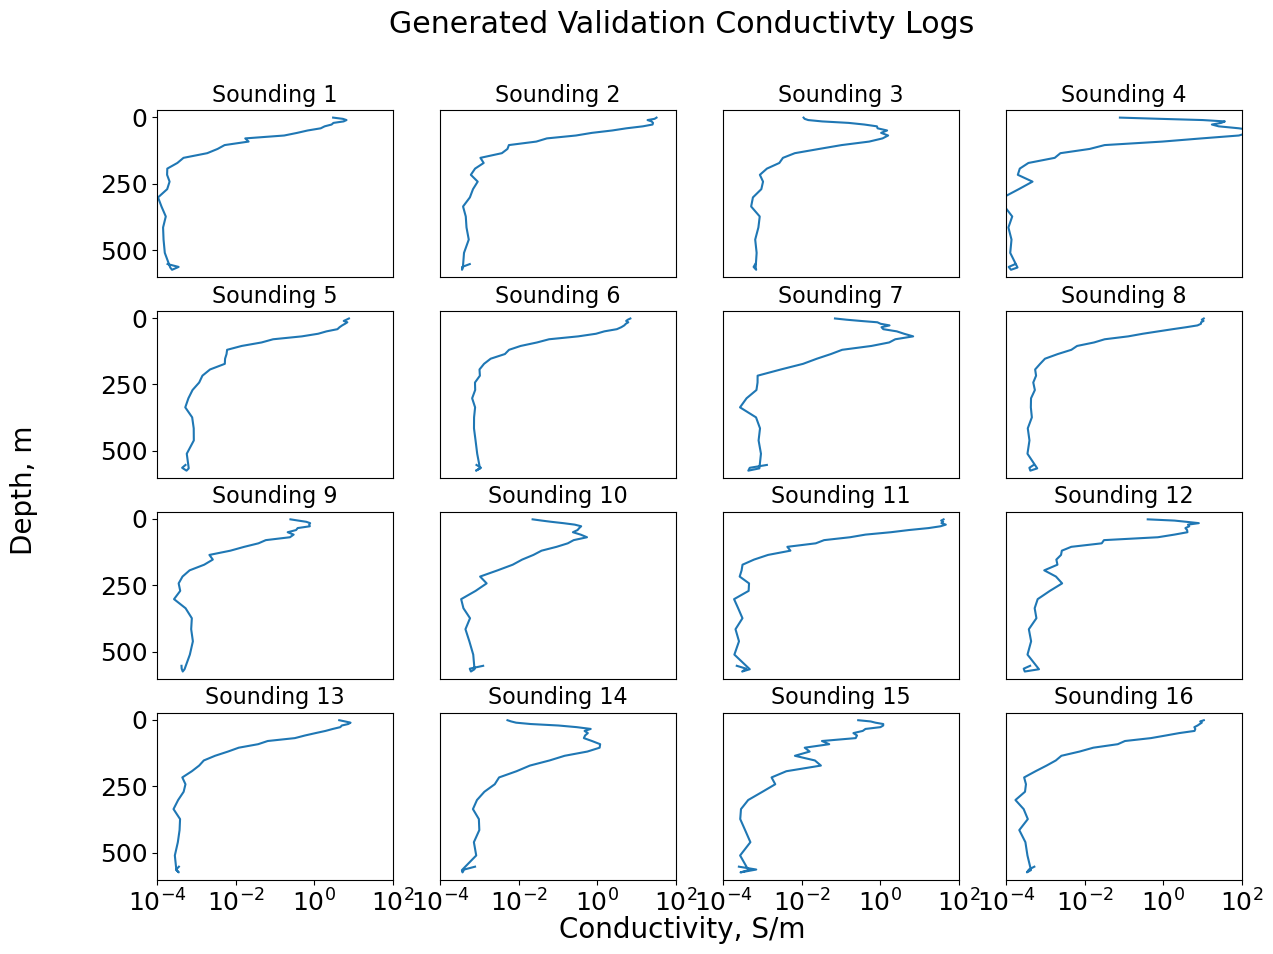

In [ ]:
network.plot_models(latent=zmd3)

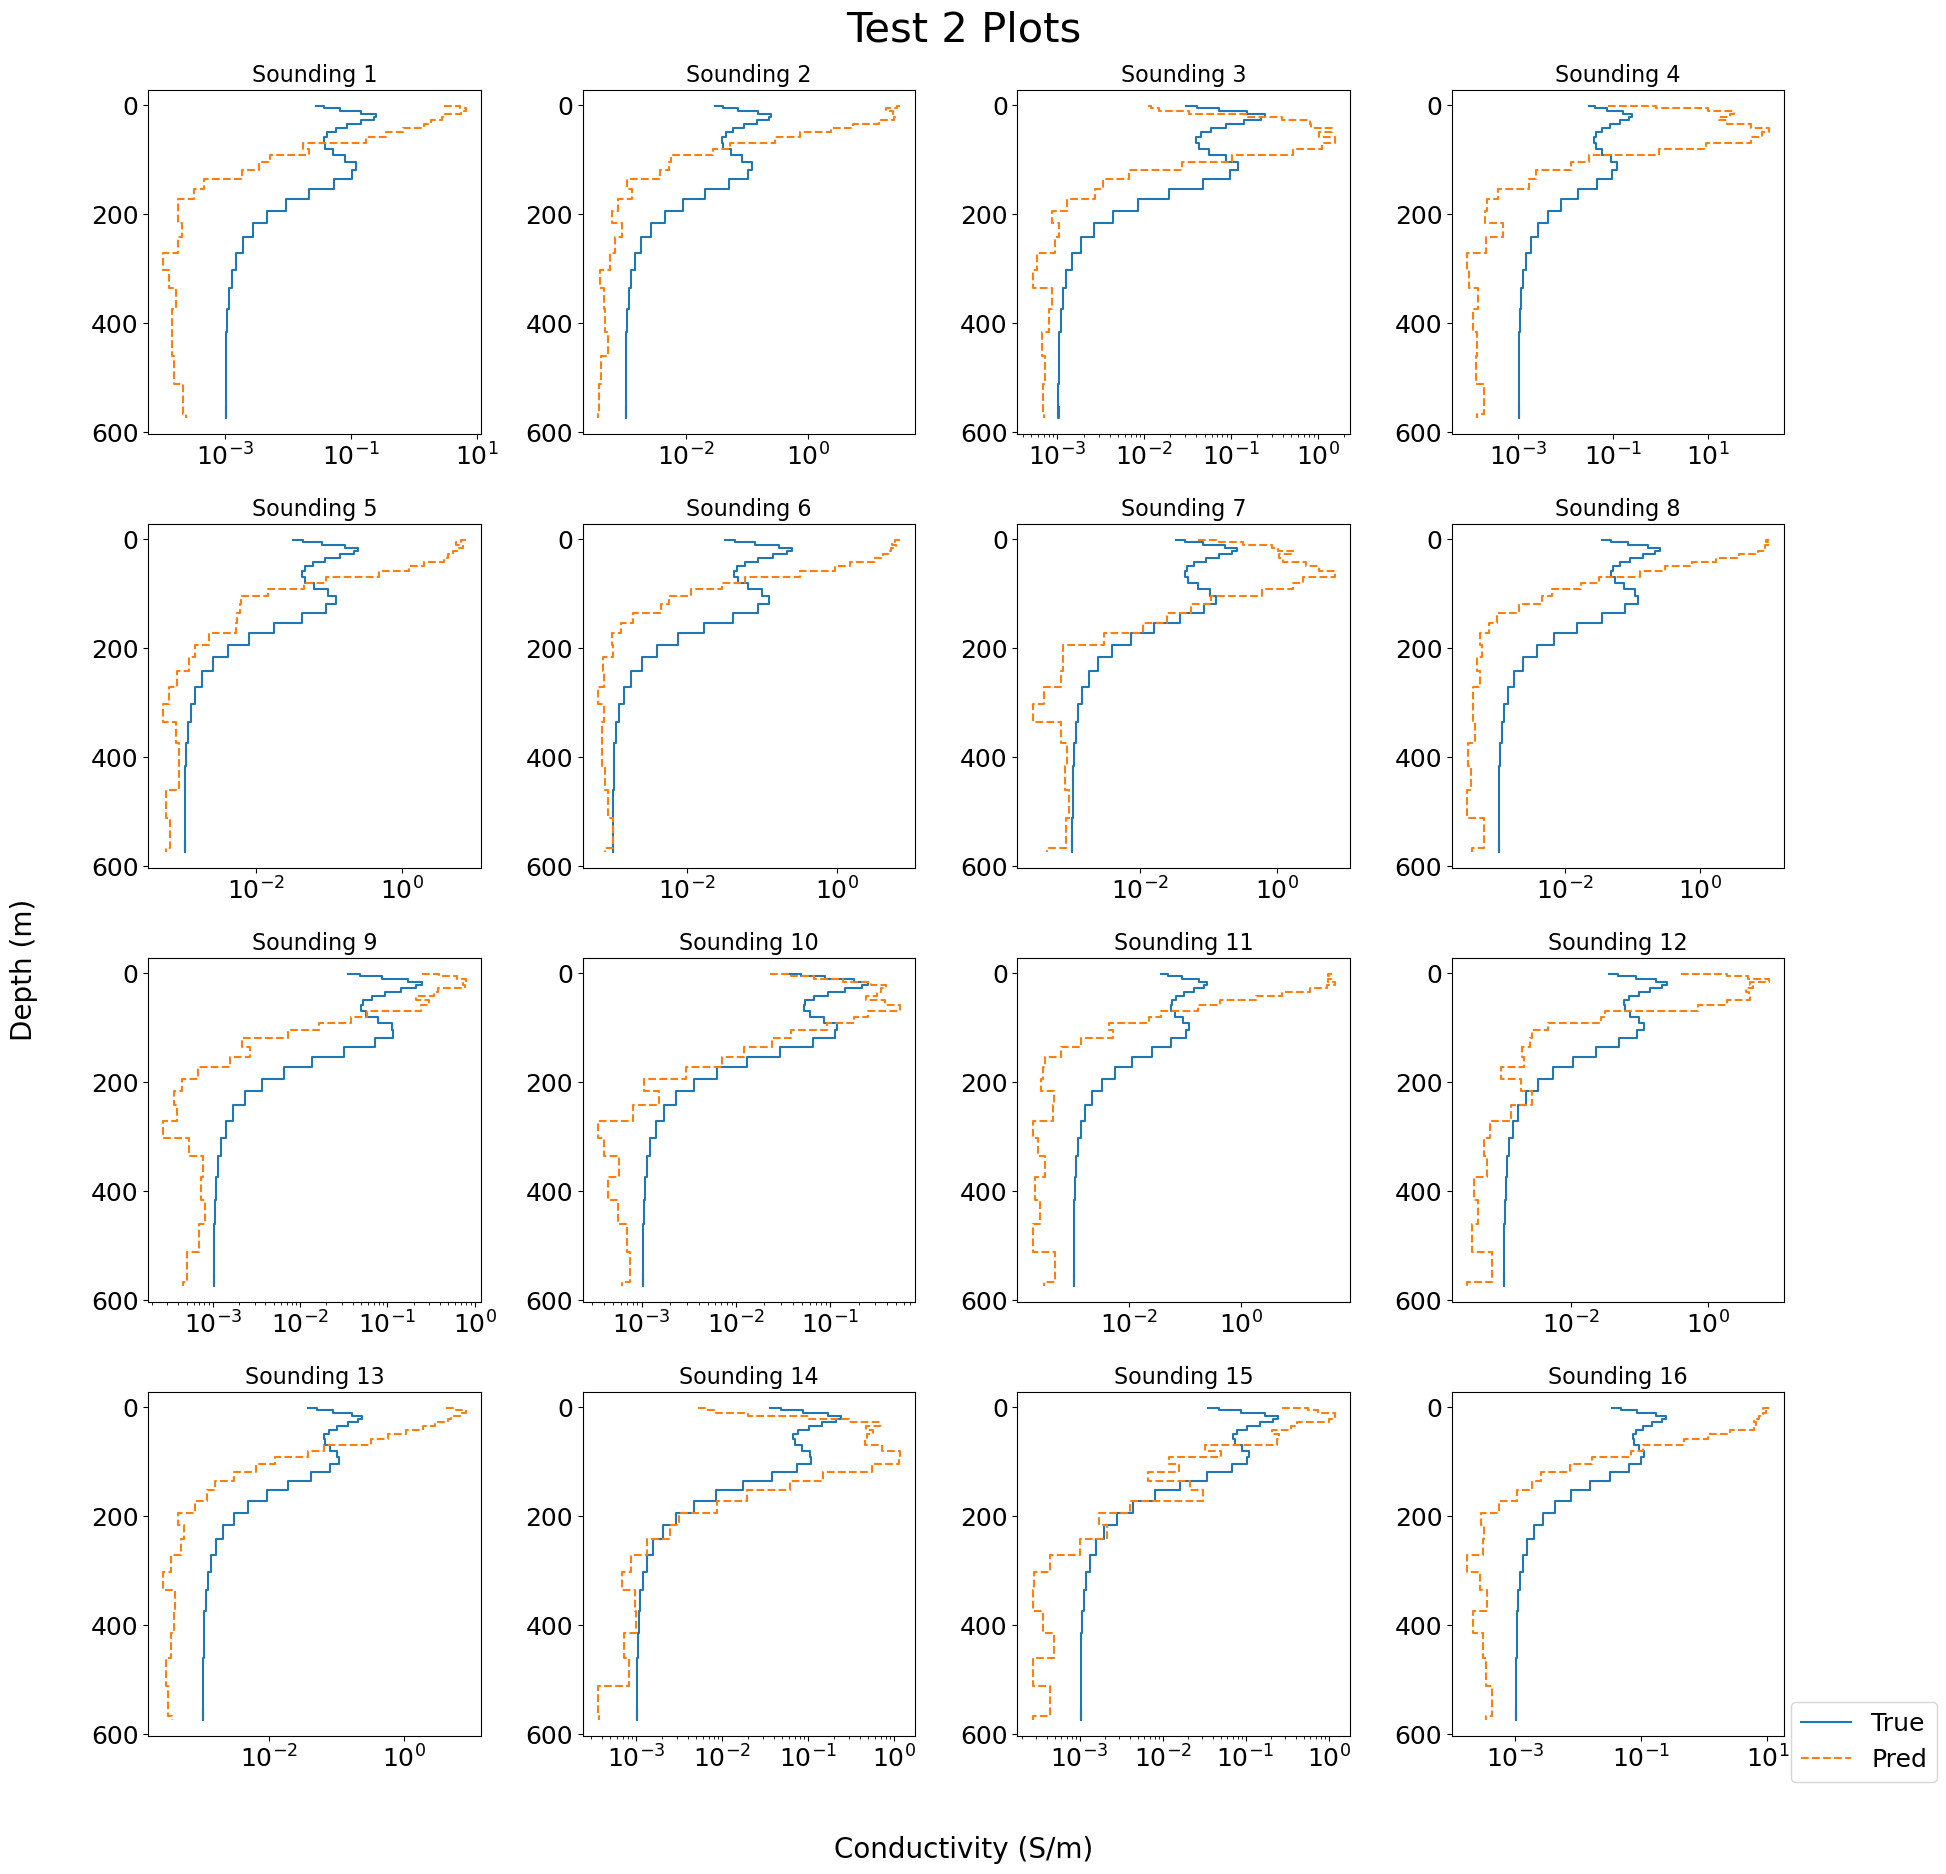

In [ ]:
# plt.figure(figsize=(20, 20))

# for i in range(16):
#     plt.subplot(4, 4, i + 1)
#     plt.plot(true_logs[i][:-2], plot_depths[:-2], drawstyle='steps-post', label='True')
#     plt.plot(np.exp(zmd3_logs[i])[:-2], plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     if i == 0:
#         plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(16):
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_logs[i]), plot_depths, drawstyle='steps-post', label='True')
        ax.semilogx(np.exp(zmd3_logs[i][:-2]), plot_depths[:-2], drawstyle='steps-post', label='Pred', linestyle='--')
        plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Test 2 Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()

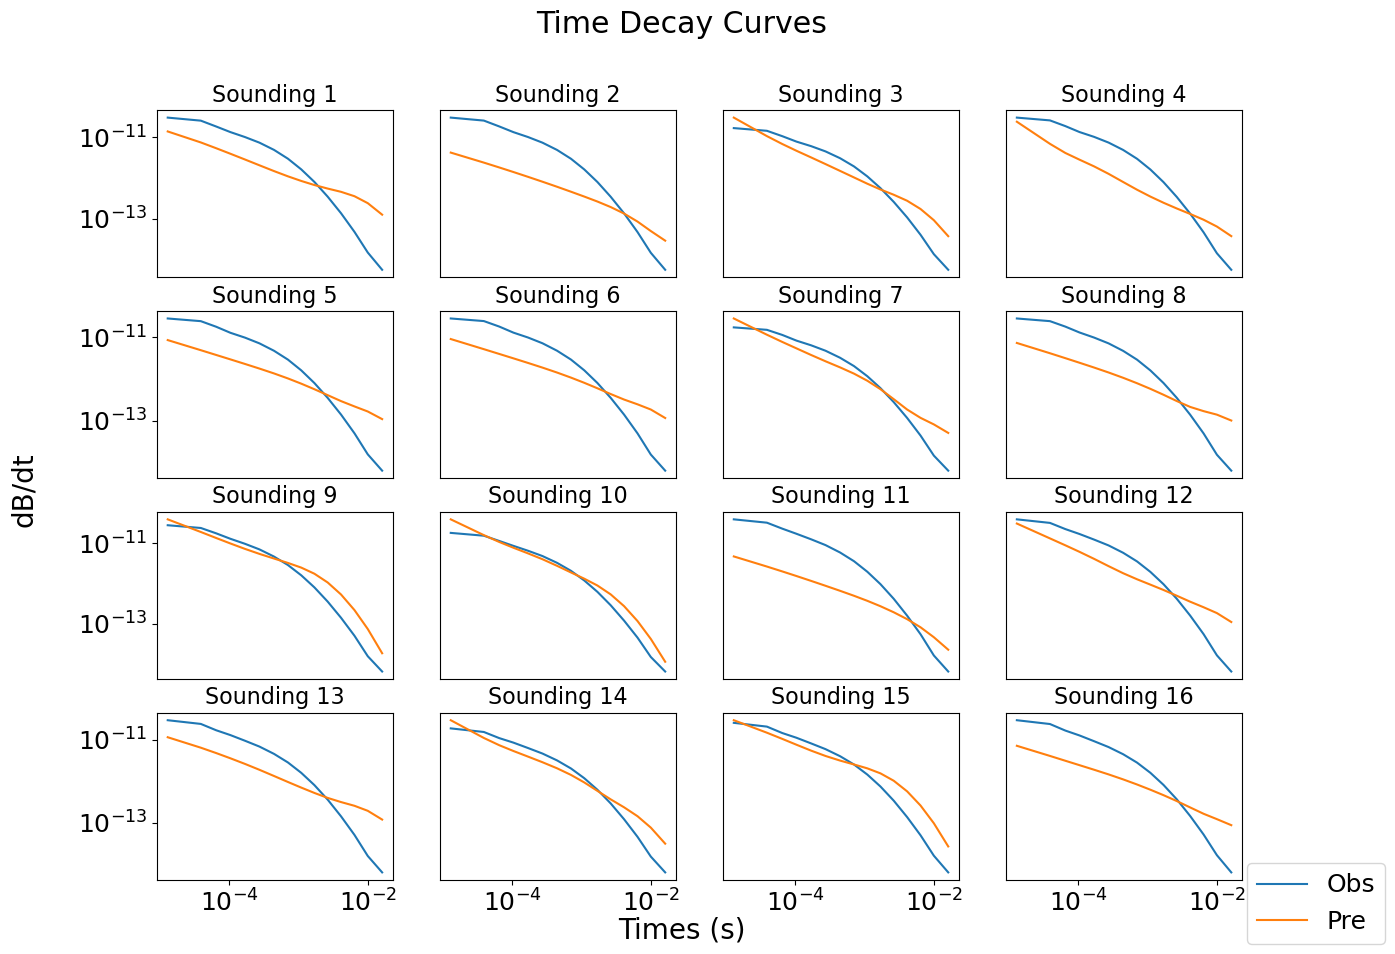

In [ ]:
network.plot_data(latent=zmd3)
# Why only one sounding???

In [ ]:
# zmd3_tanhs = network.decode(zmd3, apply_tanh=True)
# zmd3_samples = zmd3_tanhs.shape[0]
# zmd3_tanhs = np.reshape(zmd3_tanhs, (zmd3_samples, network.n_model))
# zmd3_logs = np.exp(network.tanhs_to_model(zmd3_tanhs))
# zmd3_exp = (10**zmd3_logs)

d_obs: (16, 16)
d_pre: (16, 16)
data_std: (1, 32, 1)
n_time: 16
d_std: (1, 16)
data tf.Tensor(
[[-3.87118994e-14 -2.25763473e-13 -4.46198986e-13 -4.99484948e-13
  -4.61191361e-13 -3.44986545e-13 -1.88374652e-13 -6.47126870e-14
  -4.15636103e-15 -4.18455960e-15 -1.61271397e-14 -4.40300465e-14
  -6.23139710e-14 -6.05360149e-14 -3.96124953e-14 -4.59847682e-14]
 [-6.08986535e-14 -2.87653012e-13 -5.67313991e-13 -6.27826296e-13
  -5.71410269e-13 -4.23081600e-13 -2.34784279e-13 -8.62807276e-14
  -6.77206568e-15 -1.72932635e-14 -1.22957463e-14 -1.93009586e-16
  -7.77981381e-15 -9.62370374e-15 -7.87171774e-15 -9.13774485e-15]
 [-6.12909517e-14 -8.62541917e-14 -2.35773911e-13 -2.94515822e-13
  -3.13169954e-13 -2.52341334e-13 -1.42440435e-13 -4.92942818e-14
  -3.07053573e-15 -2.01145105e-15 -1.50375944e-14 -3.24604676e-14
  -3.61561130e-14 -2.70731296e-14 -1.27227483e-14 -1.47680381e-14]
 [-1.40888498e-14 -2.27963725e-13 -4.86932109e-13 -5.43395298e-13
  -5.11733939e-13 -3.88914514e-13 -2.2121172

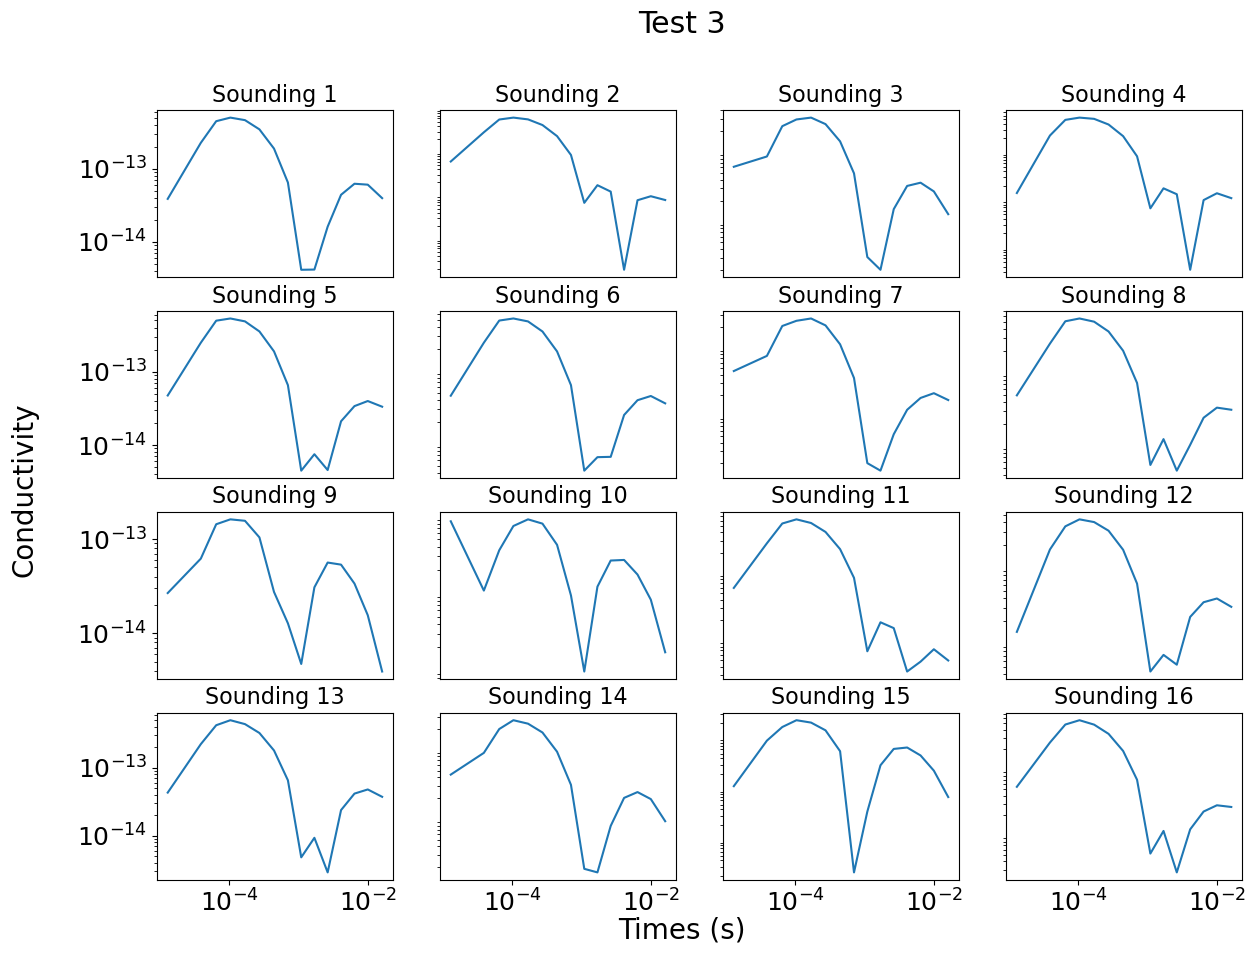

In [ ]:
network.plot_residuals(latent=zmd3, step=13)

In [ ]:
true_models3 = np.squeeze(true_logs)
true_models3 = true_models3[0:16,]

model_rmse3 = rmse(zmd3_logs, true_models3)
model_mae3 = mae(zmd3_logs, true_models3)
model_r23 = r2_score(zmd3_logs.flatten(), true_models3.flatten())

layer_rmse3 = np.sqrt(np.mean((zmd3_logs- true_models3) ** 2, axis=0))

print("Layer-wise RMSE shape:", layer_rmse3)  # (32,)

print("Model RMSE:", model_rmse3)
print("Model MAE:", model_mae3)
print("Model R2:", model_r23)

Layer-wise RMSE shape: [4.23818555 4.16979324 3.93633751 3.52817807 3.01572055 3.00535594
 3.13271599 3.36995353 3.47493426 3.26163864 2.9639446  2.01158843
 1.56431187 2.22285962 2.58329187 2.86804467 2.74950732 2.408187
 2.18476963 1.89115632 1.34323058 1.22851609 1.53716629 1.38757325
 1.05036894 1.15096844 1.02098345 1.10552378 0.87498494 1.07933753
 1.02360917 0.98131971]
Model RMSE: 2.489767258006766
Model MAE: 1.9870360814830177
Model R2: 0.5897446305793168


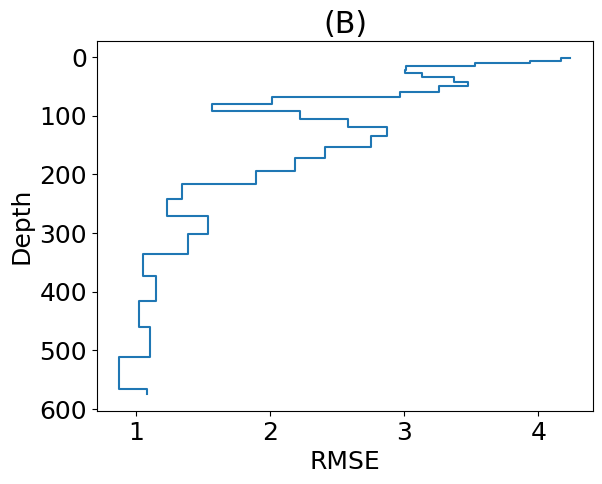

In [ ]:
plt.plot(layer_rmse3[:-2],plot_depths[:-2], drawstyle='steps-post')
plt.gca().invert_yaxis()
plt.title('(B)')
plt.xlabel('RMSE')
plt.ylabel('Depth')
plt.show()

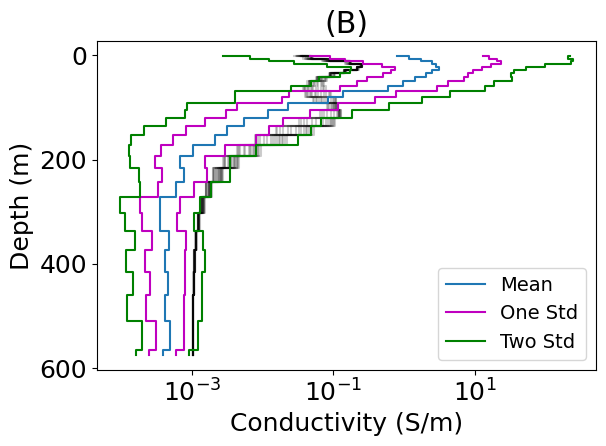

In [ ]:
mean_cond3 = np.mean(zmd3_logs,axis=0)
# mean_true_cond2 = np.mean(true_models2, axis=0)
std_cond3 = np.std(zmd3_logs,axis=0)

fig, ax = plt.subplots()
for log in true_models3:
    ax.plot(np.exp(log[:-2]), plot_depths[:-2],drawstyle='steps-post', c='k', alpha=0.2)
ax.plot(np.exp(mean_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post',label='Mean')
ax.plot(np.exp(mean_cond3[:-2]+std_cond3[:-2]),plot_depths[:-2], drawstyle='steps-post', c='m', label="One Std")
ax.plot(np.exp(mean_cond3[:-2]-std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='m')
ax.plot(np.exp(mean_cond3[:-2]+2*std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g', label= 'Two Std') # type: ignore
ax.plot(np.exp(mean_cond3[:-2]-2*std_cond3[:-2]), plot_depths[:-2], drawstyle='steps-post', c='g')
# ax.plot(true_test1[1],plot_depths, c='orange', label = 'True Mean')
ax.invert_yaxis()
ax.axes.set_xlabel("Conductivity (S/m)")
ax.axes.set_ylabel("Depth (m)")
ax.axes.set_xscale('log')
# ax.axes.set_xlim(1e-1, 1e3)
ax.axes.set_title('(B)')
ax.axes.legend(fontsize=14)

plt.tight_layout()
plt.savefig('Preliminary_generated_plots_mean&2std.jpg')
plt.show()

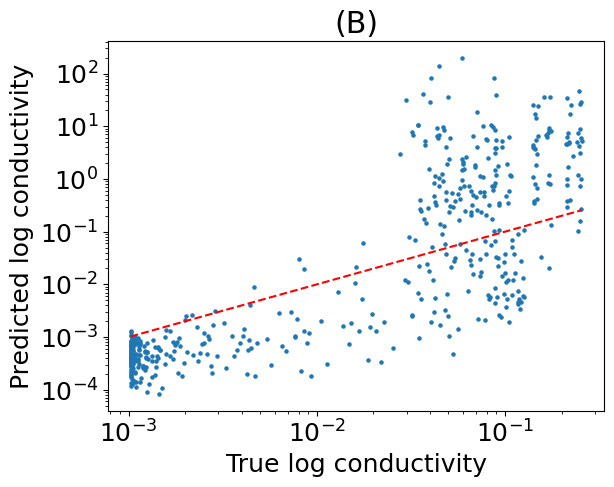

In [ ]:
true_test2_flat = true_models3.flatten()
pred_test2_flat = zmd3_logs.flatten()
plt.scatter(np.exp(true_test2_flat[:-2]), np.exp(pred_test2_flat[:-2]), s=5)

plt.plot([np.exp(true_models3.min()), np.exp(true_models3.max())],
         [np.exp(true_models3.min()), np.exp(true_models3.max())],
         'r--')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("True log conductivity")
plt.ylabel("Predicted log conductivity")

plt.title('(B)')

# plt.legend()
plt.show()

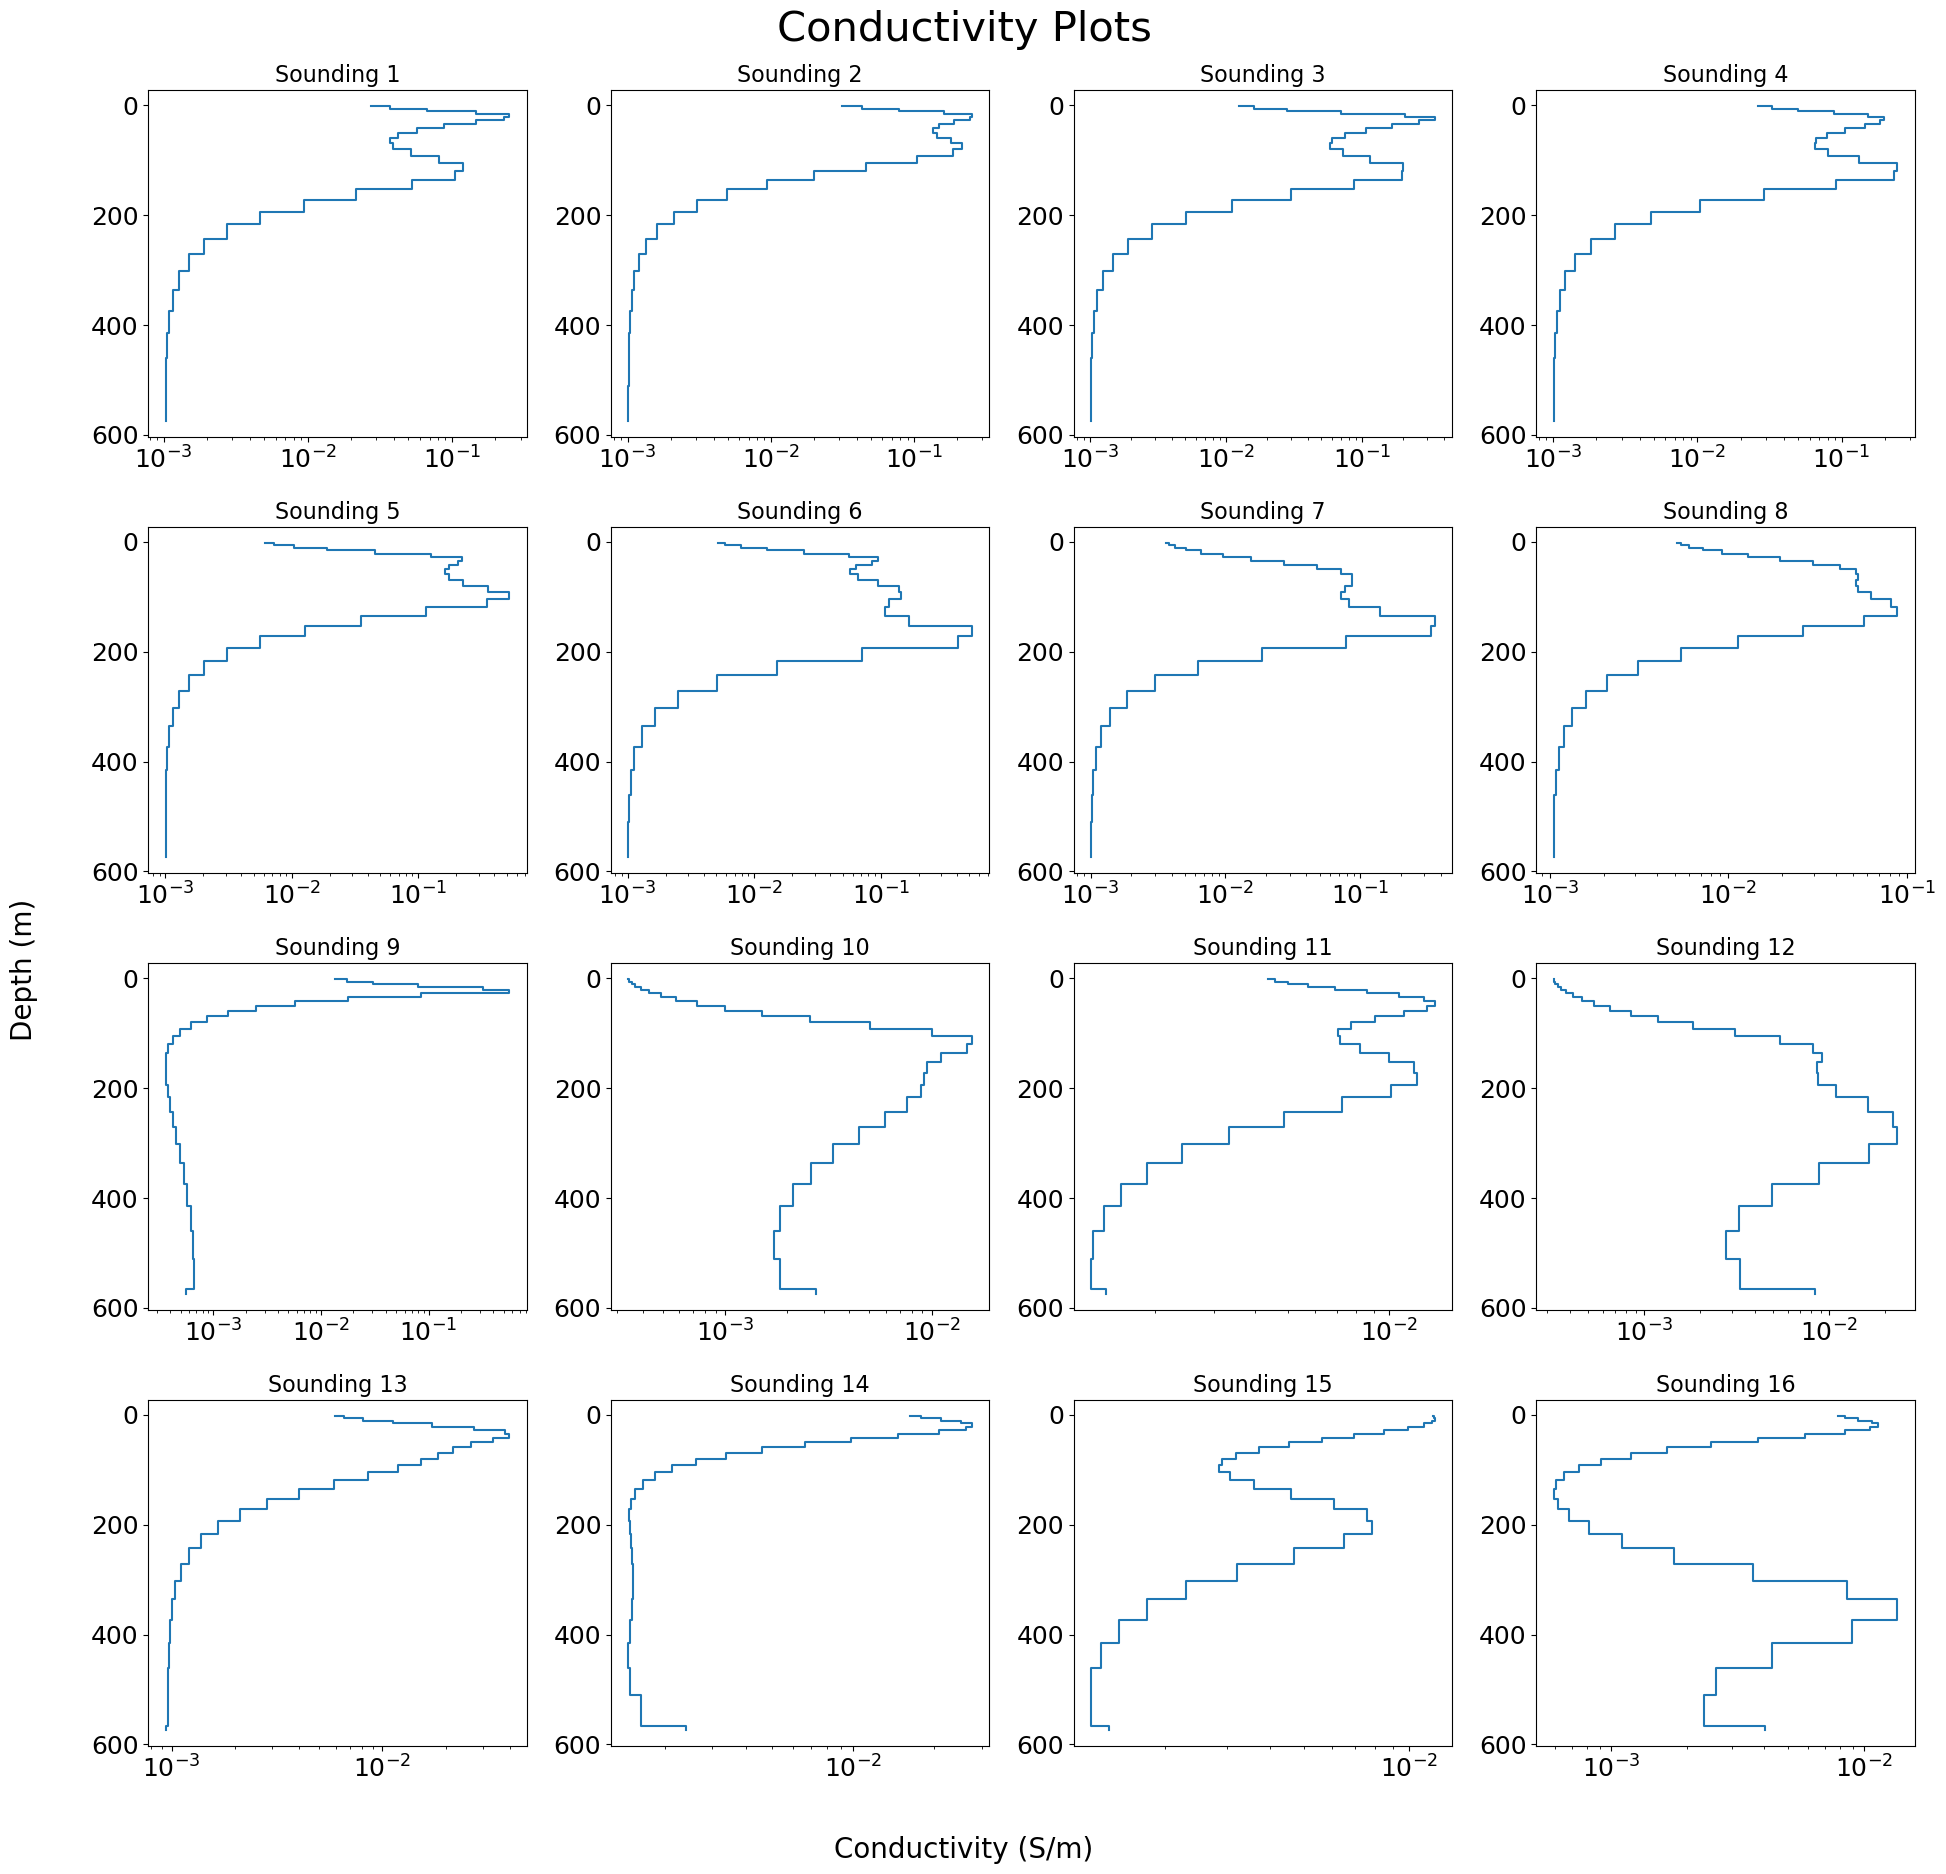

In [ ]:
# plt.figure(figsize=(20, 20))

array1 = np.array(range(0,1600,100))
# print(array1)

# print(true_logs.shape)
# for i in range(len(array1)):
#     j = array1[i]
#     plt.subplot(4, 4,  i+1)
#     plt.plot(true_logs[j][:-2], plot_depths[:-2], drawstyle='steps-post')
#     plt.xscale('log')
#     plt.gca().invert_yaxis()
#     # if i == 0:
#     #     plt.legend()
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(20, 20))
# samples = data.shape[0]
subplot_rows = 4
subplot_cols = 4
for i in range(len(array1)):
        j = array1[i]
        ax = plt.subplot(subplot_rows, subplot_cols, i+1)
        ax.set_title('Sounding %d' %int(i+1), fontsize = 16)
        ax.semilogx(np.exp(true_logs[j][:-2]), plot_depths[:-2], drawstyle='steps-post', label='True')
        plt.gca().invert_yaxis()
# plt.legend(bbox_to_anchor=(1.02, 0.1), loc='upper left', borderaxespad=0)
fig.text(0.5, 0.06, 'Conductivity (S/m)', ha='center', va='center', size=20)
fig.text(0.03, 0.5, 'Depth (m)', ha='center', va='center',
             rotation='vertical', size=20)
plt.suptitle('Conductivity Plots',fontsize = 30)
plt.tight_layout(rect=(0.05,0.08,1,1))
plt.show()